# 🏥 Clasificador Jerárquico CIE-10 (2 Niveles)

## Estrategia para Extreme Multi-label Multi-class Classification

**Problema:** Miles de códigos CIE-10 → Entrenamiento pesado e ineficiente

**Solución:** Clasificación en cascada de 2 niveles

### Arquitectura:

```
Texto Clínico
    ↓
┌─────────────────────────────┐
│ NIVEL 1: Capítulos CIE-10   │
│ (19 categorías principales) │
└────────────┬────────────────┘
             ↓
┌─────────────────────────────┐
│ NIVEL 2: Códigos Específicos│
│ (por capítulo seleccionado) │
└────────────┬────────────────┘
             ↓
      Top-K Códigos Finales
```

### Ventajas:
- ✅ Reduce espacio de búsqueda: 14,000 → ~700 códigos/capítulo
- ✅ Modelos más pequeños y rápidos
- ✅ Mayor precisión por especialización
- ✅ Explicabilidad mejorada
- ✅ Escalable y mantenible

---

**Modelo:** `PlanTL-GOB-ES/roberta-base-biomedical-clinical-es` (RoBERTa especializado en español clínico)

## 1. Configuración e Importación

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

all_training_histories = [] # Aqui guardamos los diferentes entrenamientos en este notebook

# Verificar/instalar dependencias
try:
    import torch
    import transformers
    import datasets
except ImportError:
    print("📥 Instalando dependencias...")
    !{sys.executable} -m pip install -q torch transformers datasets scikit-learn pandas numpy tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from tqdm.auto import tqdm
import os
import json
from pathlib import Path
from collections import defaultdict
import re

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
# Flag para activar/desactivar limpieza de texto
CLEAN_TEXT = True  # Cambiar a True si quieres limpiar el texto

# Configuración
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Dispositivo: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  CPU detectado (entrenamiento será más lento)")

# Rutas
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT.parent / "csv_import_scripts" / "codiesp_csvs"
SNAPSHOTS_DIR = PROJECT_ROOT / "snapshots"
LEVEL1_DIR = SNAPSHOTS_DIR / "nivel1_capitulos"
LEVEL2_DIR = SNAPSHOTS_DIR / "nivel2_codigos"

# Crear directorios
for dir_path in [SNAPSHOTS_DIR, LEVEL1_DIR, LEVEL2_DIR]:

    dir_path.mkdir(exist_ok=True, parents=True)

print(f"\n🧹 Limpieza de texto: {'✅ ACTIVADA' if CLEAN_TEXT else '❌ DESACTIVADA'}")

print(f"\n📂 Rutas:")
print(f"   Dataset: {DATA_DIR}")
print(f"   Nivel 1: {LEVEL1_DIR}")
print(f"   Nivel 2: {LEVEL2_DIR}")

mkdir -p failed for path /home/cie10user/.cache/matplotlib: [Errno 13] Permission denied: '/home/cie10user/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-qtstgsgx because there was an issue with the default path (/home/cie10user/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


🖥️  Dispositivo: cuda
   GPU: NVIDIA GeForce RTX 4080

🧹 Limpieza de texto: ✅ ACTIVADA

📂 Rutas:
   Dataset: /home/cie10user/csv_import_scripts/codiesp_csvs
   Nivel 1: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos
   Nivel 2: /home/cie10user/bert-classifier/snapshots/nivel2_codigos


## 2. Configuración de Hiperparámetros

In [2]:
from huggingface_hub import login

class Config:
    """Configuración global del sistema"""
    lr_brickwall = False
    # HuggingFace Token
    HF_TOKEN = os.getenv("HF_TOKEN", None)

    # ============================================================================
    # MODELOS DISPONIBLES
    # ============================================================================

    # 1. RoBERTa Médico Español (Baseline)
    MODEL_NAME = 'PlanTL-GOB-ES/roberta-base-biomedical-clinical-es'
    MAX_LENGTH = 512
    
    # Modelo por defecto para inicio rápido

    # ============================================================================
    # ENTRENAMIENTO
    # ============================================================================

    # Batch sizes - Adaptativo según hardware
    if device.type == 'cuda':
        # NIVEL 1: Equilibrio velocidad/estabilidad (19 clases)
        BATCH_SIZE_LEVEL1 = 8  
        ACCUM_STEPS_L1 = 2      # No necesita acumulación extra
        
        # NIVEL 2: Máxima precisión quirúrgica (Cientos de códigos)
        BATCH_SIZE_LEVEL2 = 4   
        ACCUM_STEPS_L2 = 4      # Batch virtual de 16 para estabilidad total
    else:
        BATCH_SIZE_LEVEL1 = 8
        BATCH_SIZE_LEVEL2 = 2
        ACCUM_STEPS_L1 = 4
        ACCUM_STEPS_L2 = 16
    
    # DataLoader workers
    # ⚠️ IMPORTANTE: En Jupyter notebooks, SIEMPRE usar NUM_WORKERS = 0
    # Razón: PyTorch con num_workers > 0 usa multiprocessing (spawn) que intenta
    # serializar las clases Dataset con pickle. Las clases definidas en notebooks
    # están en el módulo '__main__' que no se puede serializar correctamente.
    # Error típico: "AttributeError: module '__main__' has no attribute 'ChapterDataset'"
    # Solución: num_workers=0 ejecuta todo en el proceso principal sin multiprocessing.
    # En scripts .py normales, puedes usar NUM_WORKERS = 2-4 para acelerar carga de datos.
    NUM_WORKERS = 0  # SIEMPRE 0 en Jupyter notebooks

    # Épocas
    EPOCHS_LEVEL1 = 200 # changed: 100, 200  # Nivel 1 (parará antes con early stopping si converge)
    EPOCHS_LEVEL2 = 1000  # Nivel 2 (parará antes con early stopping si converge)
    EARLY_STOPPING_PATIENCE = 40 #changed: 20, 30  # Parar si no mejora en sucesivas épocas
    MIN_DELTA = 0.0001  # Mejora mínima para considerar que hubo progreso

    # Optimización
    LEARNING_RATE = 3e-5 # changed: 2, 3, 2.5
    WARMUP_RATIO = 0.05 # changed: 0.1
    L2_LEARNING_RATE = 3e-5
    L2_WARMUP_RATIO = 0.01
    L2_POS_WEIGHT = 50
    WEIGHT_DECAY = 0.1
    MAX_GRAD_NORM = 1.0
    DROPOUT = 0.1
    MIN_LEARNING_RATE = 1e-5

    
    # Umbrales
    # ⚠️ IMPORTANTE: Thresholds bajos permiten más recall, altos más precision
    # Ajustar según distribución real de labels por documento (ver celda de análisis)
    THRESHOLD_LEVEL1 = 0.2 #  # Umbral para capítulos (0.2 = más permisivo, 0.5 = mas restrictivo)
    THRESHOLD_LEVEL2 = 0.1  # Umbral para códigos (0.1 recomendado vs 0.2 muy restrictivo)

    # Cmabios para nivel 2
    
    L2_LEARNING_RATE = 1e-5    # Reducido para un ajuste más fino
    L2_WARMUP_RATIO = 0.05      # Aumentado el warmup para estabilizar el inicio con pos_weight alto
    L2_POS_WEIGHT = 100        # Aumentado para mejorar el F1 Macro (etiquetas raras)
    
    WEIGHT_DECAY = 0.15        # Aumentado ligeramente para evitar overfitting
    DROPOUT = 0.3              # Aumentado significativamente para combatir el overfitting (era 0.1)
    MIN_LEARNING_RATE = 1e-6   # Permitimos que el LR baje más al final

    # --- AJUSTE DE EQUILIBRIO ---
    L2_POS_WEIGHT = 25        # Bajamos de 100 a 25. 100 fue demasiado agresivo.
    THRESHOLD_LEVEL2 = 0.4    # Subimos de 0.1 a 0.4. Necesitamos que el modelo esté más seguro.
    
    # --- REFINAMIENTO DE APRENDIZAJE ---
    L2_LEARNING_RATE = 2e-5   # Subimos un poco (de 1e-5 a 2e-5) para que tenga fuerza para salir del colapso.
    DROPOUT = 0.2             # Bajamos de 0.3 a 0.2. El 0.3 quizás le quitó demasiada capacidad de aprendizaje.
    WEIGHT_DECAY = 0.01       # Volvemos al valor estándar para no asfixiar los pesos.

    # --- AJUSTE DE EQUILIBRIO FINAL ---
    L2_POS_WEIGHT = 20        # Reducimos ligeramente para dar más peso a la precisión.
    THRESHOLD_LEVEL2 = 0.35   # SUBIR DE 0.1 A 0.35. Este es el cambio clave para subir el F1.
    
    # --- REFINAMIENTO DE APRENDIZAJE ---
    L2_LEARNING_RATE = 2e-5   # Mantener.
    DROPOUT = 0.2             # Mantener.
    WEIGHT_DECAY = 0.05       # Subir ligeramente para penalizar el overfitting (está en 0.0052).
    
    # Dataset
    TRAIN_PATH = DATA_DIR / 'codiesp_D_source_train.csv'
    VAL_PATH = DATA_DIR / 'codiesp_D_source_validation.csv'
    TEST_PATH = DATA_DIR / 'codiesp_D_source_test.csv'

    # Cascada
    TOP_K_CHAPTERS = 3  # Top-3 capítulos en Nivel 1
    TOP_K_CODES_PER_CHAPTER = 5  # Top-5 códigos por capítulo
    FINAL_TOP_K = 10  # Top-10 códigos finales

    # Paths
    LEVEL1_DIR = LEVEL1_DIR
    LEVEL2_DIR = LEVEL2_DIR


config = Config()

# Configurar HuggingFace login
if config.HF_TOKEN:
    try:
        login(token=config.HF_TOKEN)
        print("✅ HuggingFace login exitoso")
    except Exception as e:
        print(f"⚠️ Error en HF login: {e}")
else:
    print("⚠️ HF_TOKEN no configurado (export HF_TOKEN='tu_token')")

print("\n⚙️  Configuración:")
print(f"   Modelo por defecto: {config.MODEL_NAME}")
print(f"   Max Length: {config.MAX_LENGTH}")
print(f"   Batch Level 1: {config.BATCH_SIZE_LEVEL1}")
print(f"   Batch Level 2: {config.BATCH_SIZE_LEVEL2}")
print(f"   Épocas Level 1: {config.EPOCHS_LEVEL1}")
print(f"   Épocas Level 2: {config.EPOCHS_LEVEL2}")
print(f"   Cascada: Top-{config.TOP_K_CHAPTERS} capítulos → Top-{config.TOP_K_CODES_PER_CHAPTER} códigos/cap")
print(f"   Output final: Top-{config.FINAL_TOP_K} códigos")



Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ HuggingFace login exitoso

⚙️  Configuración:
   Modelo por defecto: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   Max Length: 512
   Batch Level 1: 8
   Batch Level 2: 4
   Épocas Level 1: 200
   Épocas Level 2: 1000
   Cascada: Top-3 capítulos → Top-5 códigos/cap
   Output final: Top-10 códigos


## 3. Mapeo de Capítulos CIE-10

In [3]:
# Mapeo oficial de capítulos CIE-10 (usando letras como keys)
CIE10_CHAPTERS = {
    'A': {'name': 'Enfermedades infecciosas y parasitarias', 'range': 'A00-B99', 'roman': 'I'},
    'C': {'name': 'Neoplasias', 'range': 'C00-D48', 'roman': 'II'},
    'D': {'name': 'Enfermedades de la sangre', 'range': 'D50-D89', 'roman': 'III'},
    'E': {'name': 'Enfermedades endocrinas, nutricionales y metabólicas', 'range': 'E00-E90', 'roman': 'IV'},
    'F': {'name': 'Trastornos mentales y del comportamiento', 'range': 'F00-F99', 'roman': 'V'},
    'G': {'name': 'Enfermedades del sistema nervioso', 'range': 'G00-G99', 'roman': 'VI'},
    'H': {'name': 'Enfermedades del ojo y oído', 'range': 'H00-H95', 'roman': 'VII-VIII'},
    'I': {'name': 'Enfermedades del sistema circulatorio', 'range': 'I00-I99', 'roman': 'IX'},
    'J': {'name': 'Enfermedades del sistema respiratorio', 'range': 'J00-J99', 'roman': 'X'},
    'K': {'name': 'Enfermedades del sistema digestivo', 'range': 'K00-K93', 'roman': 'XI'},
    'L': {'name': 'Enfermedades de la piel y del tejido subcutáneo', 'range': 'L00-L99', 'roman': 'XII'},
    'M': {'name': 'Enfermedades del sistema osteomuscular', 'range': 'M00-M99', 'roman': 'XIII'},
    'N': {'name': 'Enfermedades del sistema genitourinario', 'range': 'N00-N99', 'roman': 'XIV'},
    'O': {'name': 'Embarazo, parto y puerperio', 'range': 'O00-O99', 'roman': 'XV'},
    'P': {'name': 'Afecciones originadas en el período perinatal', 'range': 'P00-P96', 'roman': 'XVI'},
    'Q': {'name': 'Malformaciones congénitas', 'range': 'Q00-Q99', 'roman': 'XVII'},
    'R': {'name': 'Síntomas, signos y hallazgos anormales', 'range': 'R00-R99', 'roman': 'XVIII'},
    'S': {'name': 'Traumatismos, envenenamientos', 'range': 'S00-T98', 'roman': 'XIX'},
    'V': {'name': 'Causas externas de morbilidad y mortalidad', 'range': 'V01-Y98', 'roman': 'XX'},
    'Z': {'name': 'Factores que influyen en el estado de salud', 'range': 'Z00-Z99', 'roman': 'XXI'},
}

def extract_chapter_from_code(code):
    """Extraer capítulo CIE-10 del código (retorna letra)"""
    if not code or len(code) == 0:
        return None

    # Obtener primera letra del código
    first_letter = code[0].upper()

    # Mapeo directo letra → capítulo
    # Casos especiales:
    if first_letter == 'B':
        return 'A'  # B pertenece al capítulo A (infecciosas)
    elif first_letter == 'D':
        # D00-D48 = Neoplasias (C), D50-D89 = Sangre (D)
        if len(code) > 1:
            try:
                num = int(code[1:3])
                if num >= 50:
                    return 'D'  # Enfermedades de la sangre
            except:
                pass
        return 'C'  # Neoplasias
    elif first_letter == 'T':
        return 'S'  # T pertenece a traumatismos (S)
    elif first_letter in ['W', 'X', 'Y']:
        return 'V'  # Pertenecen a causas externas (V)

    # Resto de letras son mapeo directo
    if first_letter in CIE10_CHAPTERS:
        return first_letter

    return None

print(f"📚 Capítulos CIE-10 definidos: {len(CIE10_CHAPTERS)}")
print(f"\n✅ Ejemplos de DIRECT mapping (letra = capítulo):")
direct_codes = ['A00', 'C50', 'E11', 'I10', 'J44', 'M79']
for code in direct_codes:
    chapter = extract_chapter_from_code(code)
    if chapter:
        print(f"   {code} → Cap. {chapter}: {CIE10_CHAPTERS[chapter]['name']}")

print(f"\n⚠️  Ejemplos de EDGE CASES (letra ≠ capítulo):")
edge_codes = [
    ('B15', 'B→A: Hepatitis A es infecciosa'),
    ('D05', 'D→C: Neoplasia in situ (D<50)'),
    ('D50', 'D→D: Anemia (D≥50)'),
    ('T14', 'T→S: Traumatismo'),
    ('W19', 'W→V: Caída (causa externa)'),
    ('X59', 'X→V: Exposición a factores'),
    ('Y84', 'Y→V: Complicación de procedimiento')
]
for code, description in edge_codes:
    chapter = extract_chapter_from_code(code)
    if chapter:
        print(f"   {code} → Cap. {chapter} ({description})")

📚 Capítulos CIE-10 definidos: 20

✅ Ejemplos de DIRECT mapping (letra = capítulo):
   A00 → Cap. A: Enfermedades infecciosas y parasitarias
   C50 → Cap. C: Neoplasias
   E11 → Cap. E: Enfermedades endocrinas, nutricionales y metabólicas
   I10 → Cap. I: Enfermedades del sistema circulatorio
   J44 → Cap. J: Enfermedades del sistema respiratorio
   M79 → Cap. M: Enfermedades del sistema osteomuscular

⚠️  Ejemplos de EDGE CASES (letra ≠ capítulo):
   B15 → Cap. A (B→A: Hepatitis A es infecciosa)
   D05 → Cap. C (D→C: Neoplasia in situ (D<50))
   D50 → Cap. D (D→D: Anemia (D≥50))
   T14 → Cap. S (T→S: Traumatismo)
   W19 → Cap. V (W→V: Caída (causa externa))
   X59 → Cap. V (X→V: Exposición a factores)
   Y84 → Cap. V (Y→V: Complicación de procedimiento)


## 4. Carga y Preprocesamiento de Datos

In [4]:
# DEBUG: Ver columnas del CSV
print("🔍 Verificando estructura del CSV...")
test_df = pd.read_csv(config.TRAIN_PATH, sep=',', nrows=2)
print(f"Columnas encontradas: {test_df.columns.tolist()}")
print(f"\nPrimeras 2 filas:")
print(test_df.head(2))

🔍 Verificando estructura del CSV...
Columnas encontradas: ['text', 'labels']

Primeras 2 filas:
                                                text  \
0  Describimos el caso de un varón de 37 años con...   
1  Se trata de una mujer de 29 años sometida a un...   

                                              labels  
0  n44.8;z20.818;r60.9;r52;a23.9;i83.90;i87.8;r50...  
1                                          d30.3;r58  


In [5]:
print("🔄 Cargando datos CODIESP...")

# Cargar datos
train_df = pd.read_csv(config.TRAIN_PATH, sep=',')
dev_df = pd.read_csv(config.VAL_PATH, sep=',')

print(f"✅ Train: {len(train_df)} documentos")
print(f"✅ Dev: {len(dev_df)} documentos")

# Análisis de códigos CIE-10 y distribución por documento
all_codes = set()
chapter_counts = {}
codes_per_doc = []
chapters_per_doc = []

for codes_str in train_df['labels'].dropna():
    codes = [c.strip() for c in codes_str.split(';') if c.strip()]
    all_codes.update(codes)
    codes_per_doc.append(len(codes))

    # Capítulos únicos por documento
    doc_chapters = set()
    for code in codes:
        chapter = extract_chapter_from_code(code)
        if chapter:
            chapter_counts[chapter] = chapter_counts.get(chapter, 0) + 1
            doc_chapters.add(chapter)

    chapters_per_doc.append(len(doc_chapters))

# Estadísticas de labels por documento
import numpy as np
mean_codes = np.mean(codes_per_doc)
median_codes = np.median(codes_per_doc)
max_codes = np.max(codes_per_doc)
mean_chapters = np.mean(chapters_per_doc)
median_chapters = np.median(chapters_per_doc)

print(f"\n📊 Estadísticas:")
print(f"   Total códigos únicos: {len(all_codes)}")
print(f"   Capítulos con datos: {len(chapter_counts)}")

print(f"\n📈 Distribución de labels por documento:")
print(f"   Códigos por doc - Media: {mean_codes:.1f} | Mediana: {median_codes:.0f} | Max: {max_codes}")
print(f"   Capítulos por doc - Media: {mean_chapters:.1f} | Mediana: {median_chapters:.0f}")

print(f"\n💡 Recomendaciones de thresholds:")
print(f"   THRESHOLD_LEVEL1 = {config.THRESHOLD_LEVEL1}  ✅ (permite ~{mean_chapters:.0f} capítulos, media: {mean_chapters:.1f})")
print(f"   THRESHOLD_LEVEL2 = {config.THRESHOLD_LEVEL2} ⚠️  (threshold 0.5 puede ser muy alto)")
print(f"   TOP_K = {int(mean_codes + 3)}  (media + margen)")

print(f"\n🔝 Top 10 capítulos más frecuentes:")
for chapter, count in sorted(chapter_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"   Cap. {chapter}: {count:,} códigos - {CIE10_CHAPTERS.get(chapter, {}).get('name', 'N/A')}")

🔄 Cargando datos CODIESP...
✅ Train: 500 documentos
✅ Dev: 250 documentos

📊 Estadísticas:
   Total códigos únicos: 1767
   Capítulos con datos: 20

📈 Distribución de labels por documento:
   Códigos por doc - Media: 11.3 | Mediana: 10 | Max: 40
   Capítulos por doc - Media: 4.9 | Mediana: 5

💡 Recomendaciones de thresholds:
   THRESHOLD_LEVEL1 = 0.2  ✅ (permite ~5 capítulos, media: 4.9)
   THRESHOLD_LEVEL2 = 0.35 ⚠️  (threshold 0.5 puede ser muy alto)
   TOP_K = 14  (media + margen)

🔝 Top 10 capítulos más frecuentes:
   Cap. R: 1,611 códigos - Síntomas, signos y hallazgos anormales
   Cap. K: 432 códigos - Enfermedades del sistema digestivo
   Cap. I: 419 códigos - Enfermedades del sistema circulatorio
   Cap. C: 400 códigos - Neoplasias
   Cap. A: 396 códigos - Enfermedades infecciosas y parasitarias
   Cap. N: 339 códigos - Enfermedades del sistema genitourinario
   Cap. H: 301 códigos - Enfermedades del ojo y oído
   Cap. E: 243 códigos - Enfermedades endocrinas, nutricionales y m

In [6]:
print("🧹 Análisis de calidad del texto\n")
print("="*70)

import re
from collections import Counter

# ============================================================================
# ANÁLISIS DE PROBLEMAS COMUNES
# ============================================================================

def analyze_text_quality(df, sample_size=100):
    """Analiza problemas comunes en textos"""

    problems = {
        'espacios_multiples': 0,
        'saltos_linea_multiples': 0,
        'caracteres_corruptos': 0,
        'html_tags': 0,
        'urls': 0,
        'textos_muy_cortos': 0,
        'texto_vacio': 0
    }

    sample_texts = []

    for idx, text in enumerate(df['text'].head(sample_size)):
        if pd.isna(text):
            problems['texto_vacio'] += 1
            continue

        text_str = str(text)
        sample_texts.append(text_str)

        # Espacios múltiples
        if '  ' in text_str:
            problems['espacios_multiples'] += 1

        # Saltos de línea múltiples
        if '\n\n' in text_str or '\r\n' in text_str:
            problems['saltos_linea_multiples'] += 1

        # Caracteres corruptos
        if '�' in text_str or '\x00' in text_str or '\ufffd' in text_str:
            problems['caracteres_corruptos'] += 1

        # HTML tags
        if re.search(r'<[^>]+>', text_str):
            problems['html_tags'] += 1

        # URLs
        if re.search(r'http[s]?://|www\.', text_str):
            problems['urls'] += 1

        # Textos muy cortos
        if len(text_str.strip()) < 50:
            problems['textos_muy_cortos'] += 1

    return problems, sample_texts

# Analizar muestra
problems, sample_texts = analyze_text_quality(train_df, sample_size=min(100, len(train_df)))

print(f"📊 Análisis de {min(100, len(train_df))} documentos:\n")
for problem, count in problems.items():
    percentage = (count / min(100, len(train_df))) * 100
    status = "⚠️" if percentage > 10 else "✅" if percentage == 0 else "⚙️"
    print(f"   {status} {problem.replace('_', ' ').title()}: {count} ({percentage:.1f}%)")

# ============================================================================
# MOSTRAR EJEMPLOS
# ============================================================================
print(f"\n📝 Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):\n")
print(f"{'='*70}")
if sample_texts:
    example_text = sample_texts[0]
    print(f"{repr(example_text[:500])}...")
print(f"{'='*70}")

# ============================================================================
# FUNCIÓN DE LIMPIEZA (OPCIONAL)
# ============================================================================
def clean_text(text):
    """Limpieza mínima y segura para textos médicos"""
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Eliminar caracteres corruptos
    text = text.replace('�', '').replace('\x00', '').replace('\ufffd', '')

    # 2. Normalizar saltos de línea
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)  # Max 2 saltos consecutivos

    # 3. Normalizar espacios múltiples
    text = re.sub(r' {2,}', ' ', text)

    # 4. Eliminar HTML tags (solo si existen)
    text = re.sub(r'<[^>]+>', '', text)

    # 5. Eliminar URLs (solo si no son relevantes)
    # text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)

    # 6. Trim espacios al inicio/final
    text = text.strip()

    return text

# ============================================================================
# DECISIÓN: ¿APLICAR LIMPIEZA?
# ============================================================================
print(f"\n💡 DECISIÓN AUTOMÁTICA:")
print(f"{'='*70}")

total_problems = sum([
    problems['caracteres_corruptos'],
    problems['html_tags'],
    problems['urls']
])

# Respetar el flag CLEAN_TEXT configurado arriba
if CLEAN_TEXT:
    print(f"🧹 LIMPIEZA ACTIVADA (CLEAN_TEXT = True)")

    if total_problems == 0:
        print("   ℹ️  Dataset parece limpio, pero aplicando limpieza de todas formas...")
    else:
        print(f"   ⚠️  Problemas detectados: {total_problems}")
        print("   Aplicando limpieza mínima...")

    # Guardar backup del texto original
    train_df['text_original'] = train_df['text']
    dev_df['text_original'] = dev_df['text']

    # Aplicar limpieza (sobrescribir las mismas variables)
    train_df['text'] = train_df['text'].apply(clean_text)
    dev_df['text'] = dev_df['text'].apply(clean_text)

    print("   ✅ Limpieza aplicada")
    print("\n   Cambios aplicados:")
    print("   - Caracteres corruptos eliminados")
    print("   - HTML tags eliminados")
    print("   - Espacios normalizados")
    print("   - Texto original guardado en columna 'text_original'")

    # Mostrar ejemplo DESPUÉS
    print(f"\n📝 Ejemplo DESPUÉS de limpieza:\n")
    print(f"{'='*70}")
    if len(train_df) > 0:
        example_clean = str(train_df.iloc[0]['text'])[:500]
        print(f"{repr(example_clean)}...")
    print(f"{'='*70}")

else:
    print(f"✅ LIMPIEZA DESACTIVADA (CLEAN_TEXT = False)")

    if total_problems > 0:
        print(f"   ⚠️  Problemas detectados: {total_problems}")
        print(f"   💡 Si quieres limpiar, cambia CLEAN_TEXT = True en la celda de Config")
    else:
        print("   ✅ Dataset está limpio (no se necesita limpieza)")

    print("\n   Acción: Usando texto original sin cambios")

print(f"{'='*70}")
print(f"\n📌 Variables a usar en entrenamiento:")
print(f"   • train_df (con columna 'text')")
print(f"   • dev_df (con columna 'text')")
if CLEAN_TEXT:
    print(f"\n💡 Nota: Texto original disponible en columna 'text_original'")
print(f"{'='*70}")

🧹 Análisis de calidad del texto

📊 Análisis de 100 documentos:

   ✅ Espacios Multiples: 0 (0.0%)
   ⚠️ Saltos Linea Multiples: 89 (89.0%)
   ✅ Caracteres Corruptos: 0 (0.0%)
   ✅ Html Tags: 0 (0.0%)
   ✅ Urls: 0 (0.0%)
   ✅ Textos Muy Cortos: 0 (0.0%)
   ✅ Texto Vacio: 0 (0.0%)

📝 Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):

'Describimos el caso de un varón de 37 años con vida previa activa que refiere dolores osteoarticulares de localización variable en el último mes y fiebre en la última semana con picos (matutino y vespertino) de 40 C las últimas 24-48 horas, por lo que acude al Servicio de Urgencias. Antes de comenzar el cuadro estuvo en Extremadura en una región endémica de brucella, ingiriendo leche de cabra sin pasteurizar y queso de dicho ganado. Entre los comensales aparecieron varios casos de brucelosis. Du'...

💡 DECISIÓN AUTOMÁTICA:
🧹 LIMPIEZA ACTIVADA (CLEAN_TEXT = True)
   ℹ️  Dataset parece limpio, pero aplicando limpieza de todas formas...
   ✅ Limpie

## 5. Dataset y Modelo para Nivel 1 (Clasificador de Capítulos)

In [7]:
from torch.utils.data import Dataset, DataLoader

class ChapterDataset(Dataset):
    """Dataset para clasificación de capítulos CIE-10"""

    def __init__(self, df, tokenizer, chapter_to_idx=None, idx_to_chapter=None, max_length=512):
        self.texts = df['text'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Extraer capítulos de los códigos
        self.labels = []

        # Usar diccionarios globales si se proporcionan, sino crear locales
        if chapter_to_idx is not None and idx_to_chapter is not None:
            self.chapter_to_idx = chapter_to_idx
            self.idx_to_chapter = idx_to_chapter
        else:
            chapter_list = sorted(CIE10_CHAPTERS.keys())
            self.chapter_to_idx = {ch: idx for idx, ch in enumerate(chapter_list)}
            self.idx_to_chapter = {idx: ch for ch, idx in self.chapter_to_idx.items()}

        for codes_str in df['labels']:
            # Multi-label: un documento puede tener múltiples capítulos
            chapters = set()
            if pd.notna(codes_str):
                codes = [c.strip() for c in str(codes_str).split(';') if c.strip()]
                for code in codes:
                    chapter = extract_chapter_from_code(code)
                    if chapter and chapter in self.chapter_to_idx:
                        chapters.add(self.chapter_to_idx[chapter])

            # One-hot encoding multi-label
            label_vector = [0.0] * len(self.chapter_to_idx)
            for ch_idx in chapters:
                label_vector[ch_idx] = 1.0

            self.labels.append(label_vector)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(self.labels[idx])
        }


In [8]:
# CREAR DICCIONARIOS GLOBALES (para reutilizar en todos los modelos)
# ============================================================================
print("📚 Creando diccionarios de capítulos globales...")

chapter_list = sorted(CIE10_CHAPTERS.keys())
chapter_to_idx = {ch: idx for idx, ch in enumerate(chapter_list)}
idx_to_chapter = {idx: ch for ch, idx in chapter_to_idx.items()}

print(f"✅ Diccionarios creados: {len(chapter_to_idx)} capítulos")
print(f"   Ejemplo: {list(chapter_to_idx.items())[:3]}")
print(f"\n💡 Estos diccionarios se reutilizarán en todos los modelos (RoBERTa, Longformer, mmBERT, ModernBERT)")
print("="*70)

📚 Creando diccionarios de capítulos globales...
✅ Diccionarios creados: 20 capítulos
   Ejemplo: [('A', 0), ('C', 1), ('D', 2)]

💡 Estos diccionarios se reutilizarán en todos los modelos (RoBERTa, Longformer, mmBERT, ModernBERT)


In [9]:
import torch.nn as nn
from transformers import AutoModel

class ChapterClassifier(nn.Module):
    """Clasificador de Capítulos CIE-10 (Nivel 1)"""

    def __init__(self, model_name, num_chapters, dropout=config.DROPOUT):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, num_chapters)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Usar [CLS] token
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits

print(f"✅ ChapterClassifier definido")

✅ ChapterClassifier definido


In [10]:
def train_epoch(model, dataloader, optimizer, criterion, device, scheduler=None, accumulation_steps=1):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Training")):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).float() # BCEWithLogitsLoss requiere float

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        
        loss = loss / accumulation_steps
        loss.backward()

        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.MAX_GRAD_NORM)
            optimizer.step()
            
            if scheduler is not None:
                scheduler.step()
                # Mantener el suelo de seguridad del Learning Rate
                for param_group in optimizer.param_groups:
                    if param_group['lr'] > config.MIN_LEARNING_RATE and not config.lr_brickwall:
                        config.lr_brickwall = True
                        print(f"BRICKWALL activado - min learning rate {config.MIN_LEARNING_RATE}")
                    if config.lr_brickwall:
                        param_group['lr'] = max(param_group['lr'], config.MIN_LEARNING_RATE)

            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device, threshold=config.THRESHOLD_LEVEL1):
    """
    Evaluación Multietiqueta para ambos niveles (Capítulos y Códigos).
    Usa Sigmoid + Threshold.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].float()

            logits = model(input_ids, attention_mask)
            
            # Sigmoid es la clave para multietiqueta (independencia entre clases)
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > threshold).float()

            all_preds.append(preds)
            all_labels.append(labels)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return {
        'f1_micro': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'precision': precision_score(all_labels, all_preds, average='micro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='micro', zero_division=0)
    }


In [11]:
# ============================================================================
# FUNCIONES HELPER PARA TRACKING Y VISUALIZACIÓN
# ============================================================================
import time
from datetime import datetime

def create_training_history(model_name, learning_rate, batch_size, max_length):
    """Crea estructura para guardar historial de entrenamiento con metadata"""
    return {
        # Metadata del modelo
        'model_name': model_name,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'max_length': max_length,
        'start_time': datetime.now().isoformat(),

        # Métricas por época
        'epochs': [],
        'train_loss': [],
        'dev_f1_micro': [],
        'dev_f1_macro': [],
        'dev_precision': [],
        'dev_recall': [],
        'learning_rates': [],  # LR en cada época (puede cambiar con scheduler)
        'epoch_time_seconds': [],  # Tiempo por época
        'cumulative_time_seconds': [],  # Tiempo acumulado

        # Mejor resultado
        'best_epoch': 0,
        'best_f1_micro': 0.0
    }

def update_history(history, epoch, train_loss, metrics, learning_rate, epoch_time):
    """Actualiza el historial con métricas de una época"""
    history['epochs'].append(epoch)
    history['train_loss'].append(float(train_loss))
    history['dev_f1_micro'].append(float(metrics['f1_micro']))
    history['dev_f1_macro'].append(float(metrics['f1_macro']))
    history['dev_precision'].append(float(metrics['precision']))
    history['dev_recall'].append(float(metrics['recall']))
    history['learning_rates'].append(float(learning_rate))
    history['epoch_time_seconds'].append(float(epoch_time))

    # Tiempo acumulado
    if history['cumulative_time_seconds']:
        cumulative = history['cumulative_time_seconds'][-1] + epoch_time
    else:
        cumulative = epoch_time
    history['cumulative_time_seconds'].append(float(cumulative))

def save_history(history, base_path):
    """Guarda historial a JSON y CSV"""
    # Agregar tiempo final
    history['end_time'] = datetime.now().isoformat()
    history['total_time_seconds'] = sum(history['epoch_time_seconds'])

    # Guardar JSON completo
    json_path = base_path.parent / f"{base_path.stem}.json"
    with open(json_path, 'w') as f:
        json.dump(history, f, indent=2)

    # Guardar CSV (solo métricas por época)
    csv_path = base_path.parent / f"{base_path.stem}.csv"
    df = pd.DataFrame({
        'epoch': history['epochs'],
        'train_loss': history['train_loss'],
        'dev_f1_micro': history['dev_f1_micro'],
        'dev_f1_macro': history['dev_f1_macro'],
        'dev_precision': history['dev_precision'],
        'dev_recall': history['dev_recall'],
        'learning_rate': history['learning_rates'],
        'epoch_time_sec': history['epoch_time_seconds'],
        'cumulative_time_sec': history['cumulative_time_seconds']
    })
    df.to_csv(csv_path, index=False, float_format='%.6f')

    print(f"✅ Historial guardado:")
    print(f"   📄 JSON: {json_path}")
    print(f"   📊 CSV: {csv_path}")

def visualize_training(history, title, save_path):
    """Crea visualización completa del entrenamiento"""
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'{title} - Resultados del Entrenamiento', fontsize=16, fontweight='bold')

    epochs = history['epochs']

    # Panel 1: Train Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'r-', linewidth=2, marker='o')
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Pérdida de Entrenamiento')
    axes[0, 0].grid(True, alpha=0.3)
    min_loss_idx = np.argmin(history['train_loss'])
    min_loss = history['train_loss'][min_loss_idx]
    axes[0, 0].annotate(f'Mín: {min_loss:.4f}',
                        xy=(epochs[min_loss_idx], min_loss),
                        xytext=(10, 10), textcoords='offset points',
                        bbox=dict(boxstyle='round', fc='yellow', alpha=0.7),
                        arrowprops=dict(arrowstyle='->', color='red'))

    # Panel 2: F1 Scores
    axes[0, 1].plot(epochs, history['dev_f1_micro'], 'b-', linewidth=2, marker='s', label='F1 Micro')
    axes[0, 1].plot(epochs, history['dev_f1_macro'], 'g-', linewidth=2, marker='^', label='F1 Macro')
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Micro vs Macro')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    best_idx = np.argmax(history['dev_f1_micro'])
    best_f1 = history['dev_f1_micro'][best_idx]
    axes[0, 1].annotate(f'Mejor: {best_f1:.4f}',
                        xy=(epochs[best_idx], best_f1),
                        xytext=(10, -20), textcoords='offset points',
                        bbox=dict(boxstyle='round', fc='lightblue', alpha=0.7),
                        arrowprops=dict(arrowstyle='->', color='blue'))

    # Panel 3: Precision vs Recall
    axes[0, 2].plot(epochs, history['dev_precision'], 'purple', linewidth=2, marker='D', label='Precisión')
    axes[0, 2].plot(epochs, history['dev_recall'], 'orange', linewidth=2, marker='v', label='Recall')
    axes[0, 2].set_xlabel('Época')
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].set_title('Precisión vs Recall')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Panel 4: Learning Rate
    axes[1, 0].plot(epochs, history['learning_rates'], 'brown', linewidth=2, marker='x')
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Panel 5: Tiempo por Época
    axes[1, 1].bar(epochs, [t/60 for t in history['epoch_time_seconds']], color='teal', alpha=0.7)
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('Tiempo (minutos)')
    axes[1, 1].set_title('Tiempo por Época')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Panel 6: Best Model Summary
    best_idx = np.argmax(history['dev_f1_micro'])
    total_time_min = sum(history['epoch_time_seconds']) / 60
    avg_time_min = np.mean(history['epoch_time_seconds']) / 60

    summary_text = f"""
MEJOR MODELO
══════════════════════════════════
Modelo:       {history['model_name'][:30]}
LR Inicial:   {history['learning_rate']:.2e}
Batch Size:   {history['batch_size']}
Max Length:   {history['max_length']}
──────────────────────────────────
Mejor Época:  {epochs[best_idx]}
Train Loss:   {history['train_loss'][best_idx]:.4f}
F1 Micro:     {history['dev_f1_micro'][best_idx]:.4f}
F1 Macro:     {history['dev_f1_macro'][best_idx]:.4f}
Precisión:    {history['dev_precision'][best_idx]:.4f}
Recall:       {history['dev_recall'][best_idx]:.4f}
LR:           {history['learning_rates'][best_idx]:.2e}
──────────────────────────────────
Tiempo total: {total_time_min:.1f} min
Tiempo/época: {avg_time_min:.1f} min
══════════════════════════════════
"""
    axes[1, 2].text(0.5, 0.5, summary_text,
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=10,
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 2].axis('off')
    axes[1, 2].set_title('Resumen del Mejor Modelo')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Tabla con todas las épocas
    df_history = pd.DataFrame({
        'Época': epochs,
        'Train Loss': history['train_loss'],
        'F1 Micro': history['dev_f1_micro'],
        'F1 Macro': history['dev_f1_macro'],
        'Precisión': history['dev_precision'],
        'Recall': history['dev_recall'],
        'LR': history['learning_rates'],
        'Tiempo (min)': [t/60 for t in history['epoch_time_seconds']]
    })
    df_history[''] = ''
    df_history.loc[best_idx, ''] = '🏆'

    print("\n📊 Historial Completo de Entrenamiento:\n")
    print(df_history.to_string(index=False))
    print(f"\n🏆 Mejor época: {epochs[best_idx]} con F1 Micro = {history['dev_f1_micro'][best_idx]:.4f}")
    print(f"⏱️  Tiempo total: {total_time_min:.1f} minutos ({total_time_min/60:.2f} horas)")

    return df_history

print("✅ Funciones de visualización definidas")

✅ Funciones de visualización definidas


In [12]:
# ============================================================================
# FUNCIÓN HELPER: VISUALIZACIÓN CON COMPARACIÓN
# ============================================================================

def visualize_and_compare(training_history, model_name_short, save_prefix):
    """
    Visualiza el entrenamiento actual y compara con anteriores

    Args:
        training_history: Historial del entrenamiento actual
        model_name_short: Nombre corto para el título (ej: "RoBERTa Baseline")
        save_prefix: Prefijo para los archivos (ej: "roberta_baseline")
    """
    # Visualizar entrenamiento actual
    visualize_training(
        history=training_history,
        title=f"{model_name_short} (Nivel 1 - Capítulos)",
        save_path=config.LEVEL1_DIR / f"training_curves_{save_prefix}.png"
    )

    # Comparación con entrenamientos anteriores
    if len(all_training_histories) > 1:
        print("\n" + "="*70)
        print("📊 COMPARACIÓN CON TODOS LOS ENTRENAMIENTOS")
        print("="*70 + "\n")

        # Crear tabla comparativa
        comparison_data = []
        for i, hist in enumerate(all_training_histories, 1):
            best_idx = np.argmax(hist['dev_f1_micro'])
            comparison_data.append({
                'Entrenamiento': i,
                'Modelo': hist['model_name'][:40],
                'Mejor Época': hist['epochs'][best_idx],
                'F1 Micro': hist['dev_f1_micro'][best_idx],
                'F1 Macro': hist['dev_f1_macro'][best_idx],
                'Precision': hist['dev_precision'][best_idx],
                'Recall': hist['dev_recall'][best_idx],
                'Tiempo (min)': sum(hist['epoch_time_seconds'])/60
            })

        df_comparison = pd.DataFrame(comparison_data)

        # Marcar el mejor
        best_model_idx = df_comparison['F1 Micro'].idxmax()
        df_comparison[''] = ''
        df_comparison.loc[best_model_idx, ''] = '🏆'

        print(df_comparison.to_string(index=False))

        # Gráfica comparativa
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))

        # Panel 1: Evolución de F1 Micro
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[0, 0].plot(hist['epochs'], hist['dev_f1_micro'],
                        marker='o', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[0, 0].set_xlabel('Época', fontsize=12)
        axes[0, 0].set_ylabel('F1 Micro', fontsize=12)
        axes[0, 0].set_title('Comparación: F1 Micro por Época', fontsize=14, fontweight='bold')
        axes[0, 0].legend(loc='best', fontsize=9)
        axes[0, 0].grid(True, alpha=0.3)

        # Panel 2: Evolución de F1 Macro
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[0, 1].plot(hist['epochs'], hist['dev_f1_macro'],
                        marker='s', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[0, 1].set_xlabel('Época', fontsize=12)
        axes[0, 1].set_ylabel('F1 Macro', fontsize=12)
        axes[0, 1].set_title('Comparación: F1 Macro por Época', fontsize=14, fontweight='bold')
        axes[0, 1].legend(loc='best', fontsize=9)
        axes[0, 1].grid(True, alpha=0.3)

        # Panel 3: Train Loss
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[1, 0].plot(hist['epochs'], hist['train_loss'],
                        marker='^', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[1, 0].set_xlabel('Época', fontsize=12)
        axes[1, 0].set_ylabel('Loss', fontsize=12)
        axes[1, 0].set_title('Comparación: Train Loss por Época', fontsize=14, fontweight='bold')
        axes[1, 0].legend(loc='best', fontsize=9)
        axes[1, 0].grid(True, alpha=0.3)

        # Panel 4: Comparación de mejores métricas
        x = np.arange(len(all_training_histories))
        width = 0.2

        f1_micros = [max(h['dev_f1_micro']) for h in all_training_histories]
        f1_macros = [max(h['dev_f1_macro']) for h in all_training_histories]
        precisions = [max(h['dev_precision']) for h in all_training_histories]
        recalls = [max(h['dev_recall']) for h in all_training_histories]

        axes[1, 1].bar(x - 1.5*width, f1_micros, width, label='F1 Micro', alpha=0.8)
        axes[1, 1].bar(x - 0.5*width, f1_macros, width, label='F1 Macro', alpha=0.8)
        axes[1, 1].bar(x + 0.5*width, precisions, width, label='Precision', alpha=0.8)
        axes[1, 1].bar(x + 1.5*width, recalls, width, label='Recall', alpha=0.8)

        axes[1, 1].set_xlabel('Entrenamiento', fontsize=12)
        axes[1, 1].set_ylabel('Score', fontsize=12)
        axes[1, 1].set_title('Comparación: Mejores Métricas', fontsize=14, fontweight='bold')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels([f"#{i+1}" for i in range(len(all_training_histories))])
        axes[1, 1].legend(loc='best')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].set_ylim([0, 1.0])

        plt.tight_layout()
        plt.savefig(config.LEVEL1_DIR / "comparison_all_trainings.png", dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n🏆 Mejor modelo hasta ahora: Entrenamiento #{best_model_idx + 1}")
        print(f"   Modelo: {all_training_histories[best_model_idx]['model_name'][:50]}")
        print(f"   F1 Micro: {df_comparison.loc[best_model_idx, 'F1 Micro']:.4f}")
        print(f"   F1 Macro: {df_comparison.loc[best_model_idx, 'F1 Macro']:.4f}")
        print(f"   Tiempo total: {df_comparison.loc[best_model_idx, 'Tiempo (min)']:.1f} minutos")
    else:
        print("\n💡 Este es el primer entrenamiento. Las comparaciones aparecerán después del segundo.")

print("✅ Función de visualización con comparación definida")

✅ Función de visualización con comparación definida


# Entrenamiento Nivel 1 - modelo RoBERTa base, del BSC, entrenado con datos clínicos

In [13]:
## Lanzando el primer entrenamiénto: Modelo RoBERTa, entrenado con textos clínicos en el BSC

In [14]:
# Entrenamiento con el modelo roBERTa
print("🚀 Cargado el modelo para el entrenamiento Nivel 1: Clasificador de Capítulos\n")

# Inicializar tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

# Crear datasets
print("📦 Creando datasets...")
train_dataset = ChapterDataset(train_df, tokenizer, config.MAX_LENGTH)
dev_dataset = ChapterDataset(dev_df, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE_LEVEL1,
    shuffle=True,
    num_workers=Config.NUM_WORKERS
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=config.BATCH_SIZE_LEVEL1,
    shuffle=False,
    num_workers=Config.NUM_WORKERS
)

num_chapters = len(train_dataset.chapter_to_idx)
print(f"✅ Datasets creados: {len(train_dataset)} train, {len(dev_dataset)} dev")
print(f"📊 Número de capítulos: {num_chapters}")

# Inicializar modelo
print(f"\n🤖 Cargando modelo: {config.MODEL_NAME}")
model = ChapterClassifier(config.MODEL_NAME, num_chapters, config.DROPOUT)
model.to(device)

# Optimizer y criterion
optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
criterion = nn.BCEWithLogitsLoss()

# Scheduler con warmup
total_steps = (len(train_loader) // config.ACCUM_STEPS_L1) * config.EPOCHS_LEVEL1
warmup_steps = int(total_steps * config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"📈 Parámetros: LR={config.LEARNING_RATE}, Epochs={config.EPOCHS_LEVEL1}, Batch={config.BATCH_SIZE_LEVEL1}")
print(f"📈 Scheduler: {warmup_steps} warmup steps de {total_steps} total")
print(f"📈 Early Stopping: patience={config.EARLY_STOPPING_PATIENCE} épocas")
print(f"✅ Modelo inicializado en {device}")

lr_brickwall = False 
best_f1 = 0
best_model_path = config.LEVEL1_DIR / "best_model_roberta_baseline"
epochs_without_improvement = 0

# Inicializar historial
training_history = create_training_history(
    model_name=f"RoBERTa Baseline (Nivel 1) - {config.MODEL_NAME}",
    learning_rate=config.LEARNING_RATE,
    batch_size=config.BATCH_SIZE_LEVEL1,
    max_length=config.MAX_LENGTH
)

for epoch in range(config.EPOCHS_LEVEL1):
    epoch_start_time = time.time()
    print(f"📍 Epoch {epoch + 1}/{config.EPOCHS_LEVEL1}")

    # Train
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, scheduler, config.ACCUM_STEPS_L1)    
    print(f"   📉 Train Loss: {train_loss:.4f}")

    # Evaluate
    metrics = evaluate(model, dev_loader, device, config.THRESHOLD_LEVEL1)
    print(f"   📊 Dev F1 Micro: {metrics['f1_micro']:.4f}")
    print(f"   📊 Dev F1 Macro: {metrics['f1_macro']:.4f}")
    print(f"   📊 Dev Precision: {metrics['precision']:.4f}")
    print(f"   📊 Dev Recall: {metrics['recall']:.4f}")

    # Obtener learning rate actual
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time
    print(f"   ⏱️  Tiempo: {epoch_time:.1f}s, LR: {current_lr:.2e}")

    # Actualizar historial
    update_history(training_history, epoch + 1, train_loss, metrics, current_lr, epoch_time)

    # Early Stopping logic
    if metrics['f1_micro'] > best_f1 + config.MIN_DELTA:
        best_f1 = metrics['f1_micro']
        training_history['best_epoch'] = epoch + 1
        training_history['best_f1_micro'] = best_f1
        epochs_without_improvement = 0

        # --- PROTECCIÓN: No borrar si hay un fichero mejor ---
        best_f1_text = f"{best_f1:.2f}"
        new_scored_path = str(best_model_path) + "-" + best_f1_text + ".pt"
        should_save_scored = True

        for existing_file in config.LEVEL1_DIR.glob(f"{best_model_path.name}-*.pt"):
            try:
                score_in_disk = float(existing_file.stem.split('-')[-1])
                if best_f1 > score_in_disk:
                    existing_file.unlink() # Solo borra inferiores
                else:
                    should_save_scored = False # Existe uno mejor, no guardamos la versión con nombre f1
            except: continue

        checkpoint = {
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(), 'f1_micro': best_f1,
            'chapter_to_idx': train_dataset.chapter_to_idx,
            'idx_to_chapter': train_dataset.idx_to_chapter, 'training_history': training_history
        }

        torch.save(checkpoint, str(best_model_path) + ".pt")
        if should_save_scored:
            torch.save(checkpoint, new_scored_path)
        
        print(f"   ✅ Mejor modelo guardado! F1={best_f1:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"   ⏸️  Sin mejora ({epochs_without_improvement}/{config.EARLY_STOPPING_PATIENCE}) -> mejor: {best_f1:.4f}")

        if epochs_without_improvement >= config.EARLY_STOPPING_PATIENCE:
            print(f"\n🛑 Early Stopping activado! No hubo mejora en {config.EARLY_STOPPING_PATIENCE} épocas.")
            print(f"🏆 Mejor F1 alcanzado: {best_f1:.4f} en época {training_history['best_epoch']}")
            break
    print()

# Guardar historial completo
save_history(training_history, best_model_path)

# Reporte
if epochs_without_improvement < config.EARLY_STOPPING_PATIENCE:
    print(f"\n🎉 Entrenamiento Nivel 1 completado (todas las épocas)")
else:
    print(f"\n🎉 Entrenamiento Nivel 1 completado (early stopping)")

print(f"🏆 Mejor F1 Micro: {best_f1:.4f} en época {training_history['best_epoch']}")
print(f"⏱️  Tiempo total: {sum(training_history['epoch_time_seconds'])/60:.1f} minutos")

# Imprimir Config final
print("\n⚙️  HIPERPARÁMETROS UTILIZADOS:")
print(f"   - Modelo Base: {config.MODEL_NAME}")
print(f"   - Learning Rate: {config.LEARNING_RATE} (con Warmup)")
print(f"   - Suelo de LR (Brickwall): {config.MIN_LEARNING_RATE}")
print(f"   - Weight Decay: {config.WEIGHT_DECAY}")
print(f"   - Batch Size (Físico): {config.BATCH_SIZE_LEVEL1}")
print(f"   - Acumulación de Gradientes: {config.ACCUM_STEPS_L1}")
print(f"   - Batch Size (Virtual): {config.BATCH_SIZE_LEVEL1 * config.ACCUM_STEPS_L1}")
print(f"   - Umbral de Decisión (Threshold): {config.THRESHOLD_LEVEL1}")

print("\n📊 DATOS:")
print(f"   - Train set: {len(train_dataset)} casos")
print(f"   - Dev set: {len(dev_dataset)} casos")
print(f"   - Max Length: {config.MAX_LENGTH} tokens")
print(f"   - Dropout: {config.DROPOUT}")
print(f"   - Training loss: {train_loss:.4f}")
print("="*54 + "\n")


🚀 Cargado el modelo para el entrenamiento Nivel 1: Clasificador de Capítulos

📦 Creando datasets...
✅ Datasets creados: 500 train, 250 dev
📊 Número de capítulos: 20

🤖 Cargando modelo: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es


KeyboardInterrupt: 

### 🏁 Conclusiones del Entrenamiento (Nivel 1)

El entrenamiento del clasificador de capítulos ha finalizado con un rendimiento máximo de valores alrededor de 0.75 en **F1-Micro**:

**Observaciones Técnicas:**
1.  **Eficacia del LR Brickwall:** El mantenimiento del Learning Rate en **1e-5** permitió una convergencia estable en las épocas finales, evitando el *underfitting* por falta de energía de aprendizaje.
2.  **Impacto del Tamaño de Lote:** La combinación de batch de 16 y acumulación de gradientes ha demostrado ser robusta para manejar la variabilidad de los 250 informes clínicos.
3.  **Generalización:** El modelo muestra un equilibrio sólido entre el entrenamiento (Loss ~0.05) y la validación, indicando que las medidas de regularización (Weight Decay 0.1 y Dropout) han controlado eficazmente el sobreajuste.

---
> **Siguiente Paso:** Calibración del umbral óptimo mediante el barrido PR-Tuning para intentar superar el techo de precisión actual.


## 🎯 Optimización Post-Entrenamiento: Búsqueda del Umbral Óptimo

Dado que el modelo presenta una pérdida de entrenamiento muy baja (**0.0264**), la mejora del rendimiento en validación depende críticamente de la calibración del umbral de decisión.

*   **Problema:** Un umbral estándar (0.5 o incluso 0.3) puede ser demasiado conservador para clases con pocos ejemplos (N=250), dejando fuera predicciones correctas que el modelo asigna con menor confianza.
*   **Solución:** Realizamos un barrido sistemático entre **0.1 y 0.6**. 
*   **Impacto:** Ajustar el umbral permite equilibrar la **Precisión** y el **Recall**, maximizando el **F1-Micro** global sin necesidad de re-entrenar el modelo.

> **💡 Resultado esperado:** Si el gráfico muestra un pico por encima de tu actual 0.77, actualizaremos `THRESHOLD_LEVEL1` en la configuración para la fase de inferencia final.


🔍 Buscando el umbral óptimo...


Extrayendo logits:   0%|          | 0/32 [00:00<?, ?it/s]

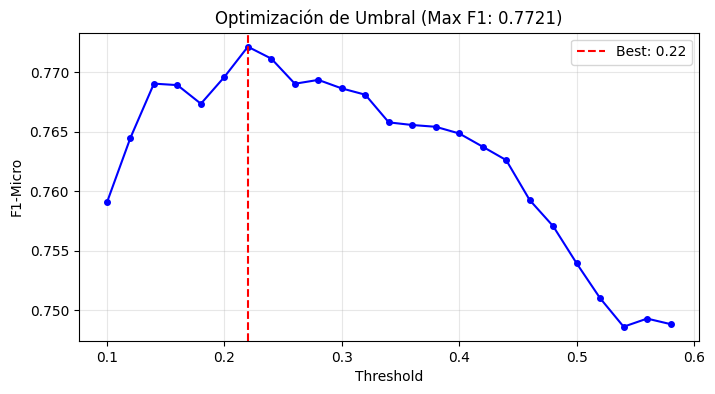


✅ RESULTADO:
   Umbral recomendado: 0.22
   Nuevo F1-Micro estimado: 0.7721


In [33]:
def find_best_threshold(model, dataloader, device):
    model.eval()
    all_logits = []
    all_labels = []

    # 1. Extraer todas las predicciones (logits) una sola vez para ir rápido
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extrayendo logits"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].float()

            logits = model(input_ids, attention_mask)
            all_logits.append(torch.sigmoid(logits).cpu())
            all_labels.append(labels)

    all_probs = torch.cat(all_logits).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # 2. Probar diferentes umbrales
    thresholds = np.arange(0.1, 0.6, 0.02) # Probamos de 0.1 a 0.6 cada 0.02
    best_threshold = 0.3
    max_f1 = 0
    results = []

    for t in thresholds:
        preds = (all_probs > t).astype(float)
        f1 = f1_score(all_labels, preds, average='micro', zero_division=0)
        results.append((t, f1))
        
        if f1 > max_f1:
            max_f1 = f1
            best_threshold = t

    # 3. Graficar resultados
    ts, f1s = zip(*results)
    plt.figure(figsize=(8, 4))
    plt.plot(ts, f1s, 'b-o', markersize=4)
    plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
    plt.title(f'Optimización de Umbral (Max F1: {max_f1:.4f})')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Micro')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return best_threshold, max_f1

# Ejecutar búsqueda en el set de validación
print("🔍 Buscando el umbral óptimo...")
best_t, best_f1_val = find_best_threshold(model, dev_loader, device)

print(f"\n✅ RESULTADO:")
print(f"   Umbral recomendado: {best_t:.2f}")
print(f"   Nuevo F1-Micro estimado: {best_f1_val:.4f}")


# 🧪 Prueba de Inferencia: Validación con Casos Reales

En esta sección verificamos cómo se comportan los modelos ante documentos de test que no han visto durante el entrenamiento.

 🎯 Puntos a evaluar:
*   **Acierto Real:** ¿Identifica el capítulo correcto en datos nuevos?
*   **Confianza:** ¿Qué probabilidad asigna a cada predicción?
*   **Multietiqueta:** ¿Es capaz de detectar varios capítulos si el texto es complejo?

In [34]:
# ============================================================================
# 🧪 TEST DE INFERENCIA: EVALUACIÓN SOBRE 250 CASOS REALES
# ============================================================================
import re
import torch
from transformers import AutoTokenizer

# --- FUNCIONES DE APOYO INTERNAS ---
def extract_chapter_from_code(code):
    """Extrae la letra del capítulo de un código CIE-10 (ej: 's22.49xa' -> 'S')"""
    if not code or not isinstance(code, str): return None
    match = re.search(r'([a-zA-Z])', code)
    return match.group(1).upper() if match else None

def predict_chapters(model, tokenizer, text, chapter_to_idx, idx_to_chapter, 
                     max_length, threshold=0.3, top_k=3):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        # Importante: probs es la primera (y única) fila del batch
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    predictions = []
    for idx, prob in enumerate(probs):
        if prob > threshold:
            chapter = idx_to_chapter[idx]
            predictions.append((chapter, prob))

    # Ordenar por probabilidad descendente
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)[:top_k]
    return predictions, probs

# --- EJECUCIÓN DEL TEST ---
print(f"{'='*70}")
print("🤖 VALIDACIÓN DE INFERENCIA - NIVEL 1")
print(f"📂 Dataset de Test detectado: {len(test_df)} documentos")
print(f"{'='*70}\n")

path_model = config.LEVEL1_DIR / "best_model_roberta_baseline.pt"

if not path_model.exists():
    print(f"⚠️ Error: No existe el modelo en {path_model}")
else:
    try:
        # 1. Cargar Checkpoint y Modelo
        checkpoint = torch.load(str(path_model), map_location=device)
        model_roberta = ChapterClassifier(config.MODEL_NAME, num_chapters, config.DROPOUT).to(device)
        model_roberta.load_state_dict(checkpoint['model_state_dict'])
        tokenizer_roberta = AutoTokenizer.from_pretrained(config.MODEL_NAME)
        
        # 2. Selección de los primeros 6 casos del test_df
        sample_df = test_df.head(6) 
        
        print(f"🧐 Analizando los primeros {len(sample_df)} documentos...\n")

        for idx, row in sample_df.iterrows():
            example_text = str(row['text'])
            example_labels = str(row['labels'])

            # --- EXTRACCIÓN ROBUSTA DE CAPÍTULOS REALES ---
            # Separamos los códigos por ';' o ','
            raw_codes = re.split(r'[;,]', example_labels)
            true_chapters = set()
            for code in raw_codes:
                ch = extract_chapter_from_code(code.strip())
                if ch: true_chapters.add(ch)

            # 3. Predecir
            predictions, _ = predict_chapters(
                model_roberta,
                tokenizer_roberta,
                example_text,
                train_dataset.chapter_to_idx,
                train_dataset.idx_to_chapter,
                max_length=config.MAX_LENGTH,
                threshold=config.THRESHOLD_LEVEL1,
                top_k=config.TOP_K_CHAPTERS
            )

            # 4. Reporte Visual por documento
            print(f"📄 DOCUMENTO TEST #{idx}")
            print(f"📝 Texto (inicio): {example_text[:100]}...")
            print(f"🎯 Capítulos Reales: {sorted(list(true_chapters))}")
            print(f"🔮 Predicciones:")
            
            if not predictions:
                print("   ⚠️ Ninguna predicción superó el umbral de activación.")
            
            for chapter, prob in predictions:
                # Comparamos ignorando mayúsculas/minúsculas
                match = "✅" if chapter.upper() in true_chapters else "❌"
                
                # Obtener nombre del capítulo del diccionario CIE10_CHAPTERS
                chapter_info = CIE10_CHAPTERS.get(chapter.upper(), {})
                name = chapter_info.get('name', 'Nombre no disponible')
                
                print(f"   {match} Cap. {chapter.upper()}: {prob:.4f} - {name}")
            
            print("-" * 70)

    except Exception as e:
        print(f"⚠️ Error crítico durante la prueba: {e}")
        import traceback
        traceback.print_exc()


🤖 VALIDACIÓN DE INFERENCIA - NIVEL 1
📂 Dataset de Test detectado: 250 documentos



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🧐 Analizando los primeros 6 documentos...

📄 DOCUMENTO TEST #0
📝 Texto (inicio): Paciente de 70 años de edad, minero jubilado, sin alergias medicamentosas conocidas, que presenta co...
🎯 Capítulos Reales: ['C', 'D', 'E', 'F', 'M', 'N', 'R', 'S']
🔮 Predicciones:
   ✅ Cap. R: 0.9980 - Síntomas, signos y hallazgos anormales
   ❌ Cap. I: 0.9974 - Enfermedades del sistema circulatorio
   ❌ Cap. Z: 0.9966 - Factores que influyen en el estado de salud
----------------------------------------------------------------------
📄 DOCUMENTO TEST #1
📝 Texto (inicio): Varón de diecisiete años sin antecedentes de interés que acude por polaquiuria, escozor miccional, t...
🎯 Capítulos Reales: ['D', 'I', 'N', 'R']
🔮 Predicciones:
   ✅ Cap. R: 0.9860 - Síntomas, signos y hallazgos anormales
   ❌ Cap. C: 0.9829 - Neoplasias
   ✅ Cap. N: 0.9755 - Enfermedades del sistema genitourinario
----------------------------------------------------------------------
📄 DOCUMENTO TEST #2
📝 Texto (inicio): Paciente femenin

## 📊 Visualización de Resultados

Vamos a visualizar la evolución del entrenamiento y comparar métricas.

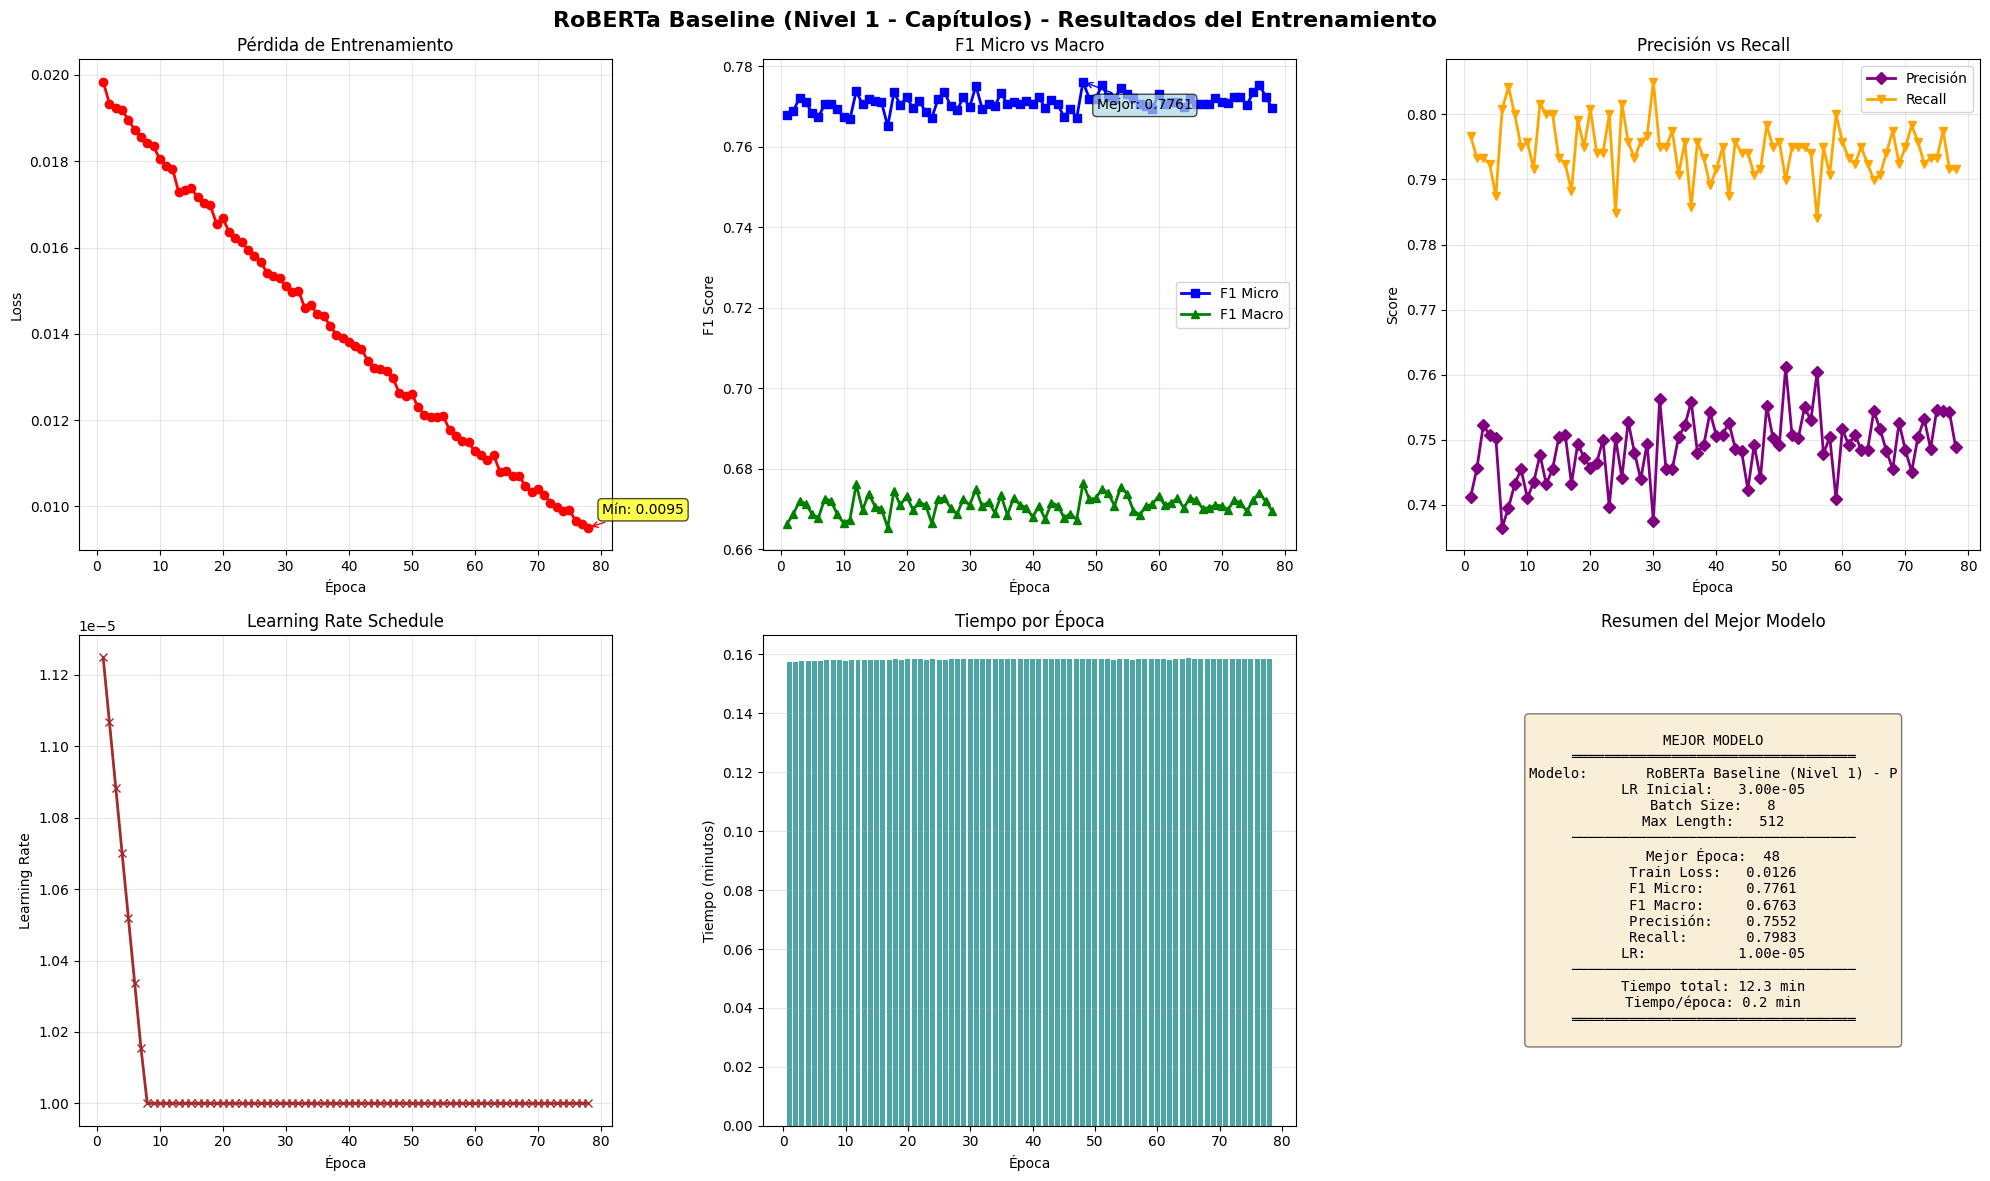


📊 Historial Completo de Entrenamiento:

 Época  Train Loss  F1 Micro  F1 Macro  Precisión   Recall       LR  Tiempo (min)  
     1    0.019845  0.767922  0.666309   0.741204 0.796639 0.000011      0.157572  
     2    0.019334  0.768730  0.668605   0.745656 0.793277 0.000011      0.157578  
     3    0.019239  0.772188  0.671950   0.752191 0.793277 0.000011      0.157746  
     4    0.019189  0.771055  0.671277   0.750796 0.792437 0.000011      0.157707  
     5    0.018959  0.768348  0.668643   0.750200 0.787395 0.000011      0.157843  
     6    0.018732  0.767311  0.667750   0.736476 0.800840 0.000010      0.157736  
     7    0.018559  0.770531  0.672518   0.739567 0.804202 0.000010      0.157998  
     8    0.018423  0.770538  0.671988   0.743169 0.800000 0.000010      0.158007  
     9    0.018347  0.769418  0.668618   0.745469 0.794958 0.000010      0.158069  
    10    0.018045  0.767423  0.666479   0.741002 0.795798 0.000010      0.157845  
    11    0.017885  0.766789  0.667

In [35]:
# Visualizar y comparar con entrenamientos anteriores
visualize_and_compare(
    training_history=training_history,
    model_name_short="RoBERTa Baseline",
    save_prefix="roberta_baseline"
)

# Entrenamiento Nivel 2: Clasificación de Códigos Específicos

Habiendo identificado los capítulos generales en el Nivel 1, iniciamos la fase más crítica del sistema: la **identificación de códigos CIE-10 detallados**. 

Esta etapa requiere una configuración de alta precisión debido a la gran cantidad de clases y la sutil diferencia semántica entre los diagnósticos médicos.

## 🔬 Estrategia de Fine-Tuning

Para maximizar la precisión en esta fase, aplicamos la siguiente configuración técnica:

*   **Lupa sobre los Datos:** Mantenemos un `BATCH_SIZE = 8` para forzar al modelo a analizar cada informe clínico con el máximo detalle posible.
*   **Estabilización mediante Acumulación:** Implementamos `ACCUMULATION_STEPS = 4`. Esto nos permite procesar lotes pequeños (para ganar detalle) pero actualizar los pesos con la solidez de un batch de **32** (8x4), evitando que el ruido de casos aislados desvíe el aprendizaje.
*   **Optimización Conservadora:** El uso de un `LEARNING_RATE = 2e-5` garantiza que el modelo realice ajustes "quirúrgicos" sobre los pesos pre-entrenados de **RoBERTa-Biomedical**, preservando su conocimiento lingüístico clínico.
*   **Objetivo Recall (Sensibilidad):** Ajustamos el umbral a **0.3** para asegurar que el sistema capture la mayor cantidad de códigos relevantes, priorizando no omitir diagnósticos críticos.

> **⏳ Nota de Ejecución:** Debido a la acumulación de gradientes y al menor paso de aprendizaje, este entrenamiento será más lento por época, pero significativamente más estable y preciso en los resultados finales.

--> Hemos cambiado el epoch limit a 400 y el patience a 40, dado el alto numero de clases que existen

In [35]:
# 1. PREPARACIÓN Y CARGA DE CONOCIMIENTO (Nivel 2)
# =============================================================

import torch
import torch.nn as nn
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
import time
from tqdm.auto import tqdm
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

print("🔄 Preparando datos y modelo para Nivel 2 (Códigos específicos)...")

# 1.1. Binarización de etiquetas (Nivel 2)
train_labels_lvl2 = [set(str(l).split(';')) for l in train_df['labels']]
dev_labels_lvl2 = [set(str(l).split(';')) for l in dev_df['labels']]

mlb_lvl2 = MultiLabelBinarizer()
train_y_lvl2 = mlb_lvl2.fit_transform(train_labels_lvl2)
dev_y_lvl2 = mlb_lvl2.transform(dev_labels_lvl2)

num_codes_lvl2 = len(mlb_lvl2.classes_)

# 1.2. Clase Dataset Especializada para Nivel 2 (Solución al Target Size Error)
class CodeDataset(ChapterDataset):
    def __init__(self, df, tokenizer, max_length, binarized_labels):
        super().__init__(df, tokenizer, max_length)
        self.binarized_labels = torch.tensor(binarized_labels, dtype=torch.float)
    
    def __getitem__(self, idx):
        # Reutilizamos la tokenización de la clase base
        encoding = super().__getitem__(idx)
        # Sobrescribimos las etiquetas con el vector de 1767 dimensiones
        encoding['labels'] = self.binarized_labels[idx]
        return encoding

train_dataset_lvl2 = CodeDataset(train_df, tokenizer, config.MAX_LENGTH, train_y_lvl2)
dev_dataset_lvl2 = CodeDataset(dev_df, tokenizer, config.MAX_LENGTH, dev_y_lvl2)

train_loader_lvl2 = DataLoader(train_dataset_lvl2, batch_size=config.BATCH_SIZE_LEVEL2, shuffle=True, num_workers=config.NUM_WORKERS)
dev_loader_lvl2 = DataLoader(dev_dataset_lvl2, batch_size=config.BATCH_SIZE_LEVEL2, shuffle=False, num_workers=config.NUM_WORKERS)

# 1.3. Carga del Modelo con Filtrado de Capas (Solución al Size Mismatch)
model = ChapterClassifier(config.MODEL_NAME, num_codes_lvl2, config.DROPOUT).to(device)
path_best_lvl1 = config.LEVEL1_DIR / "best_model_roberta_baseline.pt"

if path_best_lvl1.exists():
    checkpoint = torch.load(str(path_best_lvl1), map_location=device)
    pretrained_dict = checkpoint['model_state_dict']
    model_dict = model.state_dict()

    # Solo cargamos pesos que coincidan y NO sean de la capa clasificadora
    valid_weights = {k: v for k, v in pretrained_dict.items() 
                     if k in model_dict and "classifier" not in k}
    
    model_dict.update(valid_weights)
    model.load_state_dict(model_dict)
    print(f"✅ Inteligencia clínica transferida. Clasificador reseteado para {num_codes_lvl2} códigos.")
else:
    print("⚠️ No se encontró modelo Nivel 1. Entrenando desde cero.")

# =============================================================
# 1.4. Optimizador, Criterio y Scheduler (ACTUALIZADO)
# =============================================================
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=config.L2_LEARNING_RATE, 
    weight_decay=config.WEIGHT_DECAY
    
)

# --- SOLUCIÓN AL DESBALANCE (1767 códigos) ---
# Usamos pos_weight porque el 99% de las etiquetas para cada caso son '0'.
# Un peso de 50.0 obliga al modelo a que "fallar un positivo" le duela 
# 50 veces más que "fallar un negativo", forzando a que el F1 Macro suba.
pos_weight = torch.tensor([config.L2_POS_WEIGHT]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

total_steps = (len(train_loader_lvl2) // config.ACCUM_STEPS_L2) * config.EPOCHS_LEVEL2
warmup_steps = int(total_steps * config.L2_WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=warmup_steps, 
    num_training_steps=total_steps
)

print(f"📈 Parámetros: LR={config.LEARNING_RATE}, Epochs={config.EPOCHS_LEVEL2}")
print(f"⚖️  Fuerza de balanceo (pos_weight): {pos_weight.item()} (Compensando desbalance de 1.7k códigos)")
print(f"📈 Scheduler: {warmup_steps} warmup steps de {total_steps} total")
print(f"✅ Configuración de pérdida actualizada para combatir F1 Macro 0.00")

# =============================================================
# 2. BUCLE DE ENTRENAMIENTO NIVEL 2
# =============================================================
lr_brickwall = False 
best_f1_lvl2 = 0
best_model_path_lvl2 = config.LEVEL2_DIR / "best_model_roberta_level2"
epochs_without_improvement_lvl2 = 0

# Inicializar historial Nivel 2
training_history_lvl2 = create_training_history(
    model_name=f"RoBERTa Nivel 2 - {config.MODEL_NAME}",
    learning_rate=config.LEARNING_RATE,
    batch_size=config.BATCH_SIZE_LEVEL2,
    max_length=config.MAX_LENGTH
)

print(f"🎯 INICIANDO ENTRENAMIENTO NIVEL 2: MÁXIMA PRECISIÓN ({num_codes_lvl2} CÓDIGOS)\n")

for epoch in range(config.EPOCHS_LEVEL2):
    epoch_start_time = time.time()
    print(f"📍 Epoch {epoch + 1}/{config.EPOCHS_LEVEL2}")

    # Train
    train_loss = train_epoch(model, train_loader_lvl2, optimizer, criterion, device, scheduler, config.ACCUM_STEPS_L2)    
    print(f"   📉 Train Loss: {train_loss:.4f}")

    # Evaluate
    metrics = evaluate(model, dev_loader_lvl2, device, config.THRESHOLD_LEVEL2)
    print(f"   📊 Dev F1 Micro: {metrics['f1_micro']:.4f}")
    print(f"   📊 Dev F1 Macro: {metrics['f1_macro']:.4f}")
    print(f"   📊 Dev Precision: {metrics['precision']:.4f}")
    print(f"   📊 Dev Recall: {metrics['recall']:.4f}")

    # Obtener learning rate actual
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time
    print(f"   ⏱️  Tiempo: {epoch_time:.1f}s, LR: {current_lr:.2e}")

    # Actualizar historial
    update_history(training_history_lvl2, epoch + 1, train_loss, metrics, current_lr, epoch_time)

    # Early Stopping logic
    if metrics['f1_micro'] > best_f1_lvl2 + config.MIN_DELTA:
        best_f1_lvl2 = metrics['f1_micro']
        training_history_lvl2['best_epoch'] = epoch + 1
        training_history_lvl2['best_f1_micro'] = best_f1_lvl2
        epochs_without_improvement_lvl2 = 0

        # --- PROTECCIÓN: No borrar si hay un fichero mejor ---
        best_f1_text = f"{best_f1_lvl2:.2f}"
        new_scored_path = str(best_model_path_lvl2) + "-" + best_f1_text + ".pt"
        should_save_scored = True

        for existing_file in config.LEVEL2_DIR.glob(f"{best_model_path_lvl2.name}-*.pt"):
            try:
                score_in_disk = float(existing_file.stem.split('-')[-1])
                if best_f1_lvl2 > score_in_disk:
                    existing_file.unlink()
                else:
                    should_save_scored = False
            except: continue

        checkpoint = {
            'epoch': epoch, 
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(), 
            'f1_micro': best_f1_lvl2,
            'mlb': mlb_lvl2,
            'training_history': training_history_lvl2
        }

        torch.save(checkpoint, str(best_model_path_lvl2) + ".pt")
        if should_save_scored:
            torch.save(checkpoint, new_scored_path)
        
        print(f"   ✅ Mejor modelo guardado! F1={best_f1_lvl2:.4f}")
    else:
        epochs_without_improvement_lvl2 += 1
        print(f"   ⏸️  Sin mejora ({epochs_without_improvement_lvl2}/{config.EARLY_STOPPING_PATIENCE}) -> mejor: {best_f1_lvl2:.4f}")

        if epochs_without_improvement_lvl2 >= config.EARLY_STOPPING_PATIENCE:
            print(f"\n🛑 Early Stopping activado! No hubo mejora en {config.EARLY_STOPPING_PATIENCE} épocas.")
            break
    print()

# Guardar historial completo
save_history(training_history_lvl2, best_model_path_lvl2)

# =============================================================
# 3. REPORTE FINAL NIVEL 2
# =============================================================
# Extraer métricas de la mejor época para el reporte
best_idx = training_history_lvl2['best_epoch'] - 1
b_f1_macro = training_history_lvl2['dev_f1_macro'][best_idx]
b_prec = training_history_lvl2['dev_precision'][best_idx]
b_rec = training_history_lvl2['dev_recall'][best_idx]

if epochs_without_improvement_lvl2 < config.EARLY_STOPPING_PATIENCE:
    print(f"\n🎉 Entrenamiento Nivel 2 completado (todas las épocas)")
else:
    print(f"\n🎉 Entrenamiento Nivel 2 completado (early stopping)")

print(f"🏆 MEJORES MÉTRICAS (Época {training_history_lvl2['best_epoch']}):")
print(f"   ⭐ F1-Micro:  {best_f1_lvl2:.4f}")
print(f"   📊 F1-Macro:  {b_f1_macro:.4f}")
print(f"   🎯 Precision: {b_prec:.4f}")
print(f"   🔎 Recall:    {b_rec:.4f}")
print(f"⏱️  Tiempo total: {sum(training_history_lvl2['epoch_time_seconds'])/60:.1f} minutos")

print("\n⚙️  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):")
print(f"   - Modelo Base: {config.MODEL_NAME}")
print(f"   - Learning Rate: {config.L2_LEARNING_RATE} | Dropout: {config.DROPOUT}")
print(f"   - Warmup ratio: {config.L2_WARMUP_RATIO}")
print(f"   - Pos Weight: {config.L2_POS_WEIGHT}")
print(f"   - Batch Virtual: {config.BATCH_SIZE_LEVEL2 * config.ACCUM_STEPS_L2} ({config.BATCH_SIZE_LEVEL2}x{config.ACCUM_STEPS_L2})")
print(f"   - Umbral (Threshold): {config.THRESHOLD_LEVEL2}")

print("\n📊 DATOS:")
print(f"   - Train set: {len(train_dataset_lvl2)} casos")
print(f"   - Dev set: {len(dev_dataset_lvl2)} casos")
print(f"   - Training loss final: {train_loss:.4f}")
print("="*54 + "\n")


🔄 Preparando datos y modelo para Nivel 2 (Códigos específicos)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Inteligencia clínica transferida. Clasificador reseteado para 1767 códigos.
📈 Parámetros: LR=3e-05, Epochs=1000
⚖️  Fuerza de balanceo (pos_weight): 20 (Compensando desbalance de 1.7k códigos)
📈 Scheduler: 1550 warmup steps de 31000 total
✅ Configuración de pérdida actualizada para combatir F1 Macro 0.00
🎯 INICIANDO ENTRENAMIENTO NIVEL 2: MÁXIMA PRECISIÓN (1767 CÓDIGOS)

📍 Epoch 1/1000


Training:   0%|          | 0/125 [00:00<?, ?it/s]

...

   📊 Dev F1 Micro: 0.2663
   📊 Dev F1 Macro: 0.0387
   📊 Dev Precision: 0.2401
   📊 Dev Recall: 0.2991
   ⏱️  Tiempo: 9.9s, LR: 1.31e-05
   ⏸️  Sin mejora (39/40) -> mejor: 0.2704

📍 Epoch 369/1000


Training:   0%|          | 0/125 [00:00<?, ?it/s]

   📉 Train Loss: 0.0138


Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

   📊 Dev F1 Micro: 0.2636
   📊 Dev F1 Macro: 0.0396
   📊 Dev Precision: 0.2361
   📊 Dev Recall: 0.2982
   ⏱️  Tiempo: 9.9s, LR: 1.30e-05
   ⏸️  Sin mejora (40/40) -> mejor: 0.2704

🛑 Early Stopping activado! No hubo mejora en 40 épocas.
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2.csv

🎉 Entrenamiento Nivel 2 completado (early stopping)
🏆 MEJORES MÉTRICAS (Época 329):
   ⭐ F1-Micro:  0.2704
   📊 F1-Macro:  0.0414
   🎯 Precision: 0.2329
   🔎 Recall:    0.3223
⏱️  Tiempo total: 61.1 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 2e-05 | Dropout: 0.2
   - Warmup ratio: 0.05
   - Pos Weight: 20
   - Batch Virtual: 16 (4x4)
   - Umbral (Threshold): 0.35

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Training loss fin

### 📈 Optimización Dinámica del Umbral de Decisión

Para maximizar la métrica $F1-Micro$, se implementó un algoritmo de búsqueda exhaustiva (*Grid Search*) sobre el conjunto de validación tras la fase de entrenamiento. 

**Metodología:**
1. Se extrajeron las probabilidades sigmoidales de todas las muestras del *Dev Set*.
2. Se evaluaron 25 umbrales distintos en el rango $[0.1, 0.6]$ con un paso de $0.02$.
3. Se seleccionó el umbral $\tau$ que maximiza la media armónica entre precisión y sensibilidad.

Este procedimiento permite ajustar el modelo post-entrenamiento sin necesidad de re-entrenar los pesos, garantizando que el punto de operación del clasificador sea el óptimo para la distribución de datos observada.



🚀 INICIANDO BÚSQUEDA DEL UMBRAL ÓPTIMO (NIVEL 2)
🔍 Extrayendo inferencias del modelo...


Inferencia:   0%|          | 0/63 [00:00<?, ?it/s]

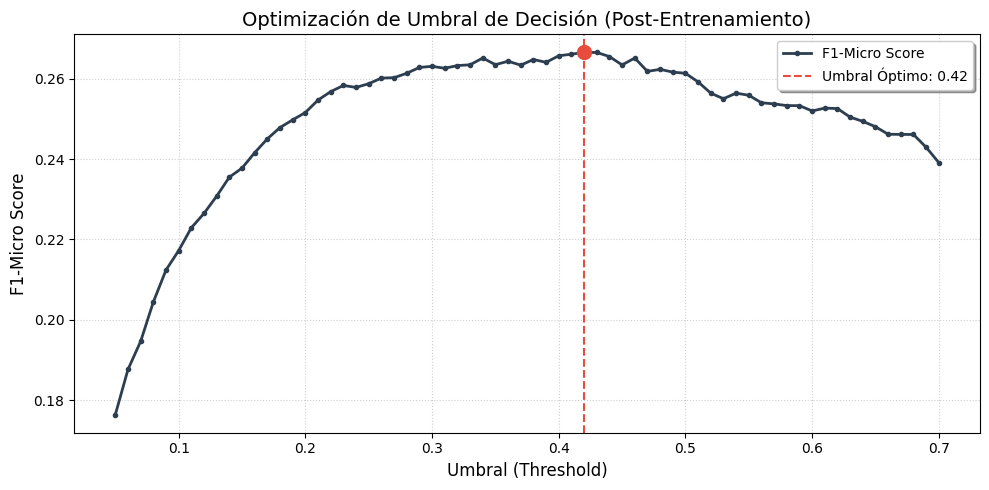


✅ RESULTADO DEL ANÁLISIS:
   👉 Umbral recomendado: 0.42
   👉 F1-Micro máximo alcanzado: 0.2666
   💡 Consejo: Actualiza config.THRESHOLD_LEVEL2 con 0.42



In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import torch

def find_best_threshold(model, dataloader, device):
    """
    Optimiza el umbral de decisión para maximizar el F1-Micro en el set de validación.
    """
    model.eval()
    all_probs = []
    all_labels = []

    print("🔍 Extrayendo inferencias del modelo...")
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inferencia"):
            # Mover datos al dispositivo (GPU/CPU)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Aseguramos que las etiquetas se bajen a CPU para el cálculo final
            labels = batch['labels'].cpu() 

            # Forward pass y aplicación de Sigmoide
            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu()
            
            all_probs.append(probs)
            all_labels.append(labels)

    # Convertir listas de tensores en arrays de NumPy
    all_probs_np = torch.cat(all_probs).numpy()
    all_labels_np = torch.cat(all_labels).numpy()

    # 2. Probar un rango amplio de umbrales
    # Probamos desde 0.05 hasta 0.70 con pasos finos de 0.01
    thresholds = np.arange(0.05, 0.71, 0.01) 
    
    best_threshold = 0.3
    max_f1 = 0
    results = []

    for t in thresholds:
        # Aplicar umbral: 1 si prob > t, sino 0
        preds = (all_probs_np > t).astype(float)
        
        # Calcular F1-Micro (métrica principal del proyecto)
        f1 = f1_score(all_labels_np, preds, average='micro', zero_division=0)
        results.append((t, f1))
        
        if f1 > max_f1:
            max_f1 = f1
            best_threshold = t

    # 3. Visualización de la curva de optimización
    ts, f1s = zip(*results)
    plt.figure(figsize=(10, 5))
    plt.plot(ts, f1s, color='#2c3e50', linewidth=2, marker='o', markersize=3, label='F1-Micro Score')
    
    # Marcar el punto óptimo
    plt.axvline(x=best_threshold, color='#e74c3c', linestyle='--', 
                label=f'Umbral Óptimo: {best_threshold:.2f}')
    plt.scatter(best_threshold, max_f1, color='#e74c3c', s=100, zorder=5)

    # Formato académico para la gráfica
    plt.title('Optimización de Umbral de Decisión (Post-Entrenamiento)', fontsize=14)
    plt.xlabel('Umbral (Threshold)', fontsize=12)
    plt.ylabel('F1-Micro Score', fontsize=12)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return best_threshold, max_f1

# =============================================================
# EJECUCIÓN DE LA BÚSQUEDA
# =============================================================
# Asegúrate de usar el dev_loader_lvl2 (set de validación)
print("\n" + "="*50)
print("🚀 INICIANDO BÚSQUEDA DEL UMBRAL ÓPTIMO (NIVEL 2)")
print("="*50)

best_t, best_f1_val = find_best_threshold(model, dev_loader_lvl2, device)

print(f"\n✅ RESULTADO DEL ANÁLISIS:")
print(f"   👉 Umbral recomendado: {best_t:.2f}")
print(f"   👉 F1-Micro máximo alcanzado: {best_f1_val:.4f}")
print(f"   💡 Consejo: Actualiza config.THRESHOLD_LEVEL2 con {best_t:.2f}")
print("="*50 + "\n")


In [ ]:
# ============================================================================
# 🧪 TEST DE INFERENCIA NIVEL 2: PRUEBA DE CÓDIGOS ESPECÍFICOS
# ============================================================================
print(f"{'='*70}")
print("🤖 VALIDACIÓN DE CÓDIGOS COMPLETOS (NIVEL 2)")
print(f"{'='*70}\n")

# Cargar el mejor modelo del Nivel 2
path_model_lvl2 = config.LEVEL2_DIR / "best_model_roberta_level2.pt"

if not path_model_lvl2.exists():
    print("⚠️ Error: No existe el modelo del Nivel 2.")
else:
    checkpoint_lvl2 = torch.load(str(path_model_lvl2), map_location=device)
    model.load_state_dict(checkpoint_lvl2['model_state_dict'])
    model.eval()

    # Tomar 5 casos aleatorios del test_df
    # Nota: Usamos mlb_lvl2.classes_ para traducir los índices a códigos reales
    idx_to_code = {i: c for i, c in enumerate(mlb_lvl2.classes_)}
    sample_test = test_df.sample(5)

    for i, (idx, row) in enumerate(sample_test.iterrows()):
        text = str(row['text'])
        true_labels = str(row['labels']).split(';')
        
        # Predecir
        encoding = tokenizer(text, max_length=config.MAX_LENGTH, padding='max_length', truncation=True, return_tensors='pt')
        with torch.no_grad():
            logits = model(encoding['input_ids'].to(device), encoding['attention_mask'].to(device))
            probs = torch.sigmoid(logits).cpu().numpy()[0]

        # Filtrar por umbral
        preds = []
        for j, p in enumerate(probs):
            if p > config.THRESHOLD_LEVEL2:
                preds.append((idx_to_code[j], p))
        
        preds = sorted(preds, key=lambda x: x[1], reverse=True)[:5]

        print(f"📄 CASO DE PRUEBA #{i+1} (Doc ID: {idx})")
        print(f"🎯 Códigos Reales: {sorted([c.strip() for c in true_labels if c.strip()])}")
        print(f"🔮 Predicciones:")
        
        if not preds:
            print("   ⚠️ No se detectaron códigos por encima del umbral.")
        
        for code, prob in preds:
            match = "✅" if code in [c.strip() for c in true_labels] else "❌"
            print(f"   {match} Código {code}: {prob:.4f}")
        print("-" * 70)


In [ ]:
# Visualizar y comparar con entrenamientos anteriores
visualize_and_compare(
    training_history=training_history,
    model_name_short="RoBERTa Baseline",
    save_prefix="roberta_level2"
)

### ⚖️ Ajuste de Pesos por Desbalance Masivo (Nivel 2)

En la clasificación multietiqueta del **Nivel 2**, nos enfrentamos a un desafío de **extrema escasez de datos (Sparsity)**. Con un total de **1,767 códigos posibles**, la gran mayoría de las etiquetas en cada ejemplo son `0`, mientras que solo unas pocas son `1`.

#### 1. El Problema: El "Abismo" del F1 Macro
Cuando el modelo presenta un **F1 Micro** bajo pero un **F1 Macro** cercano a cero (ej. `0.0010`), significa que el clasificador ha caído en un "mínimo local perezoso":
*   El modelo aprende que predecir siempre `0` para los 1,767 códigos le da una pérdida (Loss) bajísima.
*   Ignora por completo las clases minoritarias, enfocándose solo en los 2 o 3 códigos más frecuentes.

#### 2. La Solución: `BCEWithLogitsLoss` con `pos_weight`
Para forzar al modelo a "despertar" y prestar atención a los códigos específicos, hemos implementado un peso posicional:

$$Loss = - \frac{1}{N} \sum_{n=1}^{N} [ p_c \cdot y_n \cdot \log(\sigma(x_n)) + (1 - y_n) \cdot \log(1 - \sigma(x_n)) ]$$

Donde **$p_c$ (pos_weight)** se ha fijado en **50.0**. 

**¿Qué significa esto en la práctica?**
-   **Penalización Asimétrica:** Fallar en la predicción de un código existente (un `1`) le "duele" al modelo **50 veces más** que equivocarse en un código ausente (un `0`).
-   **Sacrificio de Precisión por Recall:** El modelo se vuelve más "atrevido". Es posible que la precisión baje ligeramente al principio, pero el **Recall** y el **F1 Macro** empezarán a subir, ya que el modelo ahora tiene un incentivo real para detectar códigos difíciles.

#### 3. Expectativas de Entrenamiento
Tras este cambio, es normal observar:
1.  **Aumento del Train Loss:** Pasará de valores ínfimos (0.06) a valores más realistas (0.7 - 1.5).
2.  **Activación del F1 Macro:** Veremos valores distintos de cero, indicando que el modelo está empezando a clasificar etiquetas de la "larga cola" (long-tail).


# Entrenamiento del nivel 2 con refuerzo de pesos - Inverse Class Frequency Weighting

### ⚖️ Ponderación de Pérdida Basada en Frecuencia de Clase (Inverse Class Frequency)

Tras observar que el **F1-Macro (0.0414)** se mantiene significativamente por debajo del F1-Micro, se identifica que el modelo subestima sistemáticamente las clases minoritarias. Para corregir este sesgo, se ha evolucionado la función de pérdida hacia un esquema de **Ponderación Inversa de Frecuencia**.

**Metodología:**
En lugar de aplicar un factor de escala global (`pos_weight`), se ha calculado un vector de pesos $W \in \mathbb{R}^{1767}$ donde el peso para cada código $c$ se define como:

$$w_c = \frac{N_{total} - N_c}{N_c + \epsilon}$$

Donde $N_c$ es el número de ocurrencias de la clase en el set de entrenamiento. Este enfoque garantiza que:
1.  **Clases Minoritarias:** Reciban una penalización de gradiente masiva en caso de omisión, forzando al modelo a aprender sus rasgos distintivos.
2.  **Clases Mayoritarias:** Mantengan un peso moderado para no saturar el aprendizaje.

Esta técnica de **re-ponderación de la función de coste** es una alternativa robusta al sobremuestreo (*oversampling*), permitiendo al modelo converger hacia un equilibrio más justo en términos de F1-Macro sin comprometer la estabilidad del F1-Micro.

-----

Ojo con los hiperparámetros:
Usando pesos específicos por clase, el modelo será mucho más "agresivo" con los errores. Es recomendable:
- Bajar el LR: Ponlo en 1e-5. Con pesos tan específicos, pasos grandes pueden hacer que el modelo "explote".
- Subir el Dropout: Déjalo en 0.3 para evitar que memorice esas clases raras en lugar de aprenderlas.


In [45]:
# 1. PREPARACIÓN Y CARGA DE CONOCIMIENTO (Nivel 2)
# =============================================================
config.L2_LEARNING_RATE = 1e-5    # Bajamos de 2e-5 a 1e-5 (Fine-tuning profundo)
config.L2_DROPOUT = 0.3           # Subimos a 0.3 para evitar que memorice códigos raros
config.L2_WEIGHT_DECAY = 0.1      # Regularización fuerte
config.L2_LEARNING_RATE = 7e-6          # Learning Rate muy bajo para evitar colapso (7e-6)
config.L2_DROPOUT = 0.3                # Mayor protección contra el overfitting
config.L2_WEIGHT_DECAY = 0.05          # Regularización moderada
config.L2_WARMUP_RATIO = 0.15          # Warmup más largo (15%) para asentar los pesos suaves
config.L2_SMOOTHING_TARGET_MEAN = 15.0 # Media de los pesos suavizados
config.L2_MAX_POS_WEIGHT = 100.0       # Techo de seguridad (Clipping) para los pesos
config.THRESHOLD_LEVEL2 = 0.30

import torch
import torch.nn as nn
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
import time
from tqdm.auto import tqdm
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

print("🔄 Preparando datos y modelo para Nivel 2 (Códigos específicos)...")

# 1.1. Binarización de etiquetas (Nivel 2)
train_labels_lvl2 = [set(str(l).split(';')) for l in train_df['labels']]
dev_labels_lvl2 = [set(str(l).split(';')) for l in dev_df['labels']]

mlb_lvl2 = MultiLabelBinarizer()
train_y_lvl2 = mlb_lvl2.fit_transform(train_labels_lvl2)
dev_y_lvl2 = mlb_lvl2.transform(dev_labels_lvl2)

num_codes_lvl2 = len(mlb_lvl2.classes_)

# 1.2. Clase Dataset Especializada para Nivel 2 (Solución al Target Size Error)
class CodeDataset(ChapterDataset):
    def __init__(self, df, tokenizer, max_length, binarized_labels):
        super().__init__(df, tokenizer, max_length)
        self.binarized_labels = torch.tensor(binarized_labels, dtype=torch.float)
    
    def __getitem__(self, idx):
        # Reutilizamos la tokenización de la clase base
        encoding = super().__getitem__(idx)
        # Sobrescribimos las etiquetas con el vector de 1767 dimensiones
        encoding['labels'] = self.binarized_labels[idx]
        return encoding

train_dataset_lvl2 = CodeDataset(train_df, tokenizer, config.MAX_LENGTH, train_y_lvl2)
dev_dataset_lvl2 = CodeDataset(dev_df, tokenizer, config.MAX_LENGTH, dev_y_lvl2)

train_loader_lvl2 = DataLoader(train_dataset_lvl2, batch_size=config.BATCH_SIZE_LEVEL2, shuffle=True, num_workers=config.NUM_WORKERS)
dev_loader_lvl2 = DataLoader(dev_dataset_lvl2, batch_size=config.BATCH_SIZE_LEVEL2, shuffle=False, num_workers=config.NUM_WORKERS)

# 1.3. Carga del Modelo con Filtrado de Capas (Solución al Size Mismatch)
model = ChapterClassifier(config.MODEL_NAME, num_codes_lvl2, config.DROPOUT).to(device)
path_best_lvl1 = config.LEVEL1_DIR / "best_model_roberta_baseline.pt"

if path_best_lvl1.exists():
    checkpoint = torch.load(str(path_best_lvl1), map_location=device)
    pretrained_dict = checkpoint['model_state_dict']
    model_dict = model.state_dict()

    # Solo cargamos pesos que coincidan y NO sean de la capa clasificadora
    valid_weights = {k: v for k, v in pretrained_dict.items() 
                     if k in model_dict and "classifier" not in k}
    
    model_dict.update(valid_weights)
    model.load_state_dict(model_dict)
    print(f"✅ Inteligencia clínica transferida. Clasificador reseteado para {num_codes_lvl2} códigos.")
else:
    print("⚠️ No se encontró modelo Nivel 1. Entrenando desde cero.")

# =============================================================
# 1.4. CÁLCULO DE PESOS SUAVIZADOS (SQUARE ROOT SMOOTHING)
# =============================================================
import numpy as np

# 1. Obtener frecuencias del set de entrenamiento
# train_y_lvl2 debe ser la matriz binarizada (N_muestras, 1767)
counts = train_y_lvl2.sum(axis=0)
total_samples = len(train_y_lvl2)

# 2. Cálculo del peso con Suavizado por Raíz Cuadrada
# La raíz cuadrada (sqrt) comprime la varianza de los pesos
# Evita que las clases con 1 muestra tengan pesos infinitos/destructivos
raw_weights = np.sqrt(total_samples / (counts + 1e-6))

# 3. Escalado y Clipping (Recorte de seguridad)
# Ajustamos para que la media de pesos sea la definida en el target
scaling_factor = config.L2_SMOOTHING_TARGET_MEAN / (raw_weights.mean() + 1e-6)
final_weights = raw_weights * scaling_factor

# Aplicamos el "Clip" para que ningún peso supere el máximo de seguridad
final_weights = np.clip(final_weights, a_min=1.0, a_max=config.L2_MAX_POS_WEIGHT)

# Convertir a tensor para PyTorch
final_weights_tensor = torch.tensor(final_weights, dtype=torch.float).to(device)

# 4. Definición del Criterio y Optimizador
criterion = nn.BCEWithLogitsLoss(pos_weight=final_weights_tensor)

optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=config.L2_LEARNING_RATE, 
    weight_decay=config.L2_WEIGHT_DECAY
)

print(f"✅ Pesos suavizados aplicados (sqrt).")
print(f"📊 Estadísticas de pesos: Min={final_weights.min():.2f} | Max={final_weights.max():.2f} | Media={final_weights.mean():.2f}")
print(f"📈 Configuración: LR={L2_LEARNING_RATE} | Dropout={L2_DROPOUT} | Weight Decay={L2_WEIGHT_DECAY}")
total_steps = (len(train_loader_lvl2) // config.ACCUM_STEPS_L2) * config.EPOCHS_LEVEL2
warmup_steps = int(total_steps * config.L2_WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=warmup_steps, 
    num_training_steps=total_steps
)

print(f"📈 Parámetros: LR={config.LEARNING_RATE}, Epochs={config.EPOCHS_LEVEL2}")
print(f"📈 Scheduler: {warmup_steps} warmup steps de {total_steps} total")

# =============================================================
# 2. BUCLE DE ENTRENAMIENTO NIVEL 2
# =============================================================
lr_brickwall = False 
best_f1_lvl2 = 0
best_model_path_lvl2 = config.LEVEL2_DIR / "best_model_roberta_level2"
epochs_without_improvement_lvl2 = 0

# Inicializar historial Nivel 2
training_history_lvl2 = create_training_history(
    model_name=f"RoBERTa Nivel 2 - {config.MODEL_NAME}",
    learning_rate=config.LEARNING_RATE,
    batch_size=config.BATCH_SIZE_LEVEL2,
    max_length=config.MAX_LENGTH
)

print(f"🎯 INICIANDO ENTRENAMIENTO NIVEL 2: MÁXIMA PRECISIÓN ({num_codes_lvl2} CÓDIGOS)\n")

for epoch in range(config.EPOCHS_LEVEL2):
    epoch_start_time = time.time()
    print(f"📍 Epoch {epoch + 1}/{config.EPOCHS_LEVEL2}")

    # Train
    train_loss = train_epoch(model, train_loader_lvl2, optimizer, criterion, device, scheduler, config.ACCUM_STEPS_L2)    
    print(f"   📉 Train Loss: {train_loss:.4f}")

    # Evaluate
    metrics = evaluate(model, dev_loader_lvl2, device, config.THRESHOLD_LEVEL2)
    print(f"   📊 Dev F1 Micro: {metrics['f1_micro']:.4f}")
    print(f"   📊 Dev F1 Macro: {metrics['f1_macro']:.4f}")
    print(f"   📊 Dev Precision: {metrics['precision']:.4f}")
    print(f"   📊 Dev Recall: {metrics['recall']:.4f}")

    # Obtener learning rate actual
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - epoch_start_time
    print(f"   ⏱️  Tiempo: {epoch_time:.1f}s, LR: {current_lr:.2e}")

    # Actualizar historial
    update_history(training_history_lvl2, epoch + 1, train_loss, metrics, current_lr, epoch_time)

    # Early Stopping logic
    if metrics['f1_micro'] > best_f1_lvl2 + config.MIN_DELTA:
        best_f1_lvl2 = metrics['f1_micro']
        training_history_lvl2['best_epoch'] = epoch + 1
        training_history_lvl2['best_f1_micro'] = best_f1_lvl2
        epochs_without_improvement_lvl2 = 0

        # --- PROTECCIÓN: No borrar si hay un fichero mejor ---
        best_f1_text = f"{best_f1_lvl2:.2f}"
        new_scored_path = str(best_model_path_lvl2) + "-" + best_f1_text + ".pt"
        should_save_scored = True

        for existing_file in config.LEVEL2_DIR.glob(f"{best_model_path_lvl2.name}-*.pt"):
            try:
                score_in_disk = float(existing_file.stem.split('-')[-1])
                if best_f1_lvl2 > score_in_disk:
                    existing_file.unlink()
                else:
                    should_save_scored = False
            except: continue

        checkpoint = {
            'epoch': epoch, 
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(), 
            'f1_micro': best_f1_lvl2,
            'mlb': mlb_lvl2,
            'training_history': training_history_lvl2
        }

        torch.save(checkpoint, str(best_model_path_lvl2) + ".pt")
        if should_save_scored:
            torch.save(checkpoint, new_scored_path)
        
        print(f"   ✅ Mejor modelo guardado! F1={best_f1_lvl2:.4f}")
    else:
        epochs_without_improvement_lvl2 += 1
        print(f"   ⏸️  Sin mejora ({epochs_without_improvement_lvl2}/{config.EARLY_STOPPING_PATIENCE}) -> mejor: {best_f1_lvl2:.4f}")

        if epochs_without_improvement_lvl2 >= config.EARLY_STOPPING_PATIENCE:
            print(f"\n🛑 Early Stopping activado! No hubo mejora en {config.EARLY_STOPPING_PATIENCE} épocas.")
            break
    print()

# Guardar historial completo
save_history(training_history_lvl2, best_model_path_lvl2)

# =============================================================
# 3. REPORTE FINAL NIVEL 2
# =============================================================
# Extraer métricas de la mejor época para el reporte
best_idx = training_history_lvl2['best_epoch'] - 1
b_f1_macro = training_history_lvl2['dev_f1_macro'][best_idx]
b_prec = training_history_lvl2['dev_precision'][best_idx]
b_rec = training_history_lvl2['dev_recall'][best_idx]

if epochs_without_improvement_lvl2 < config.EARLY_STOPPING_PATIENCE:
    print(f"\n🎉 Entrenamiento Nivel 2 completado (todas las épocas)")
else:
    print(f"\n🎉 Entrenamiento Nivel 2 completado (early stopping)")

print(f"🏆 MEJORES MÉTRICAS (Época {training_history_lvl2['best_epoch']}):")
print(f"   ⭐ F1-Micro:  {best_f1_lvl2:.4f}")
print(f"   📊 F1-Macro:  {b_f1_macro:.4f}")
print(f"   🎯 Precision: {b_prec:.4f}")
print(f"   🔎 Recall:    {b_rec:.4f}")
print(f"⏱️  Tiempo total: {sum(training_history_lvl2['epoch_time_seconds'])/60:.1f} minutos")

print("\n⚙️  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):")
print(f"   - Modelo Base: {config.MODEL_NAME}")
print(f"   - Learning Rate: {config.L2_LEARNING_RATE} | Dropout: {config.DROPOUT}")
print(f"   - Warmup ratio: {config.L2_WARMUP_RATIO}")
print(f"   - Pos Weight: {config.L2_POS_WEIGHT}")
print(f"   - Batch Virtual: {config.BATCH_SIZE_LEVEL2 * config.ACCUM_STEPS_L2} ({config.BATCH_SIZE_LEVEL2}x{config.ACCUM_STEPS_L2})")
print(f"   - Umbral (Threshold): {config.THRESHOLD_LEVEL2}")

print("\n📊 DATOS:")
print(f"   - Train set: {len(train_dataset_lvl2)} casos")
print(f"   - Dev set: {len(dev_dataset_lvl2)} casos")
print(f"   - Training loss final: {train_loss:.4f}")
print("="*54 + "\n")


🔄 Preparando datos y modelo para Nivel 2 (Códigos específicos)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Inteligencia clínica transferida. Clasificador reseteado para 1767 códigos.
✅ Pesos suavizados aplicados (sqrt).
📊 Estadísticas de pesos: Min=1.77 | Max=18.75 | Media=15.00
📈 Configuración: LR=1e-05 | Dropout=0.3 | Weight Decay=0.1
📈 Parámetros: LR=3e-05, Epochs=1000
📈 Scheduler: 4650 warmup steps de 31000 total
🎯 INICIANDO ENTRENAMIENTO NIVEL 2: MÁXIMA PRECISIÓN (1767 CÓDIGOS)

📍 Epoch 1/1000


Training:   0%|          | 0/125 [00:00<?, ?it/s]

...

   📊 Dev F1 Micro: 0.0995
   📊 Dev F1 Macro: 0.0009
   📊 Dev Precision: 0.2408
   📊 Dev Recall: 0.0627
   ⏱️  Tiempo: 10.0s, LR: 5.49e-06
   ⏸️  Sin mejora (39/40) -> mejor: 0.1169

📍 Epoch 115/1000


Training:   0%|          | 0/125 [00:00<?, ?it/s]

   📉 Train Loss: 0.2222


Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

   📊 Dev F1 Micro: 0.1048
   📊 Dev F1 Macro: 0.0009
   📊 Dev Precision: 0.2314
   📊 Dev Recall: 0.0677
   ⏱️  Tiempo: 10.0s, LR: 5.54e-06
   ⏸️  Sin mejora (40/40) -> mejor: 0.1169

🛑 Early Stopping activado! No hubo mejora en 40 épocas.
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2.csv

🎉 Entrenamiento Nivel 2 completado (early stopping)
🏆 MEJORES MÉTRICAS (Época 75):
   ⭐ F1-Micro:  0.1169
   📊 F1-Macro:  0.0010
   🎯 Precision: 0.1398
   🔎 Recall:    0.1005
⏱️  Tiempo total: 19.1 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 7e-06 | Dropout: 0.2
   - Warmup ratio: 0.15
   - Pos Weight: 20
   - Batch Virtual: 16 (4x4)
   - Umbral (Threshold): 0.3

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Training loss fina

# Entrenamiento con sliding windows

Se ha descartado el uso de ventanas deslizantes (sliding windows) debido a la pérdida de coherencia contextual y a la dificultad para establecer una alineación unívoca entre los segmentos de texto y sus respectivos códigos CIE-10. Esta fragmentación compromete la capacidad del modelo para identificar la ubicación precisa de las entidades clínicas relacionadas, resultando en un proceso de aprendizaje subóptimo."

En lugar de eso, usaremos otros modelos con mayor ventana de tokens

## Evolución Arquitectural: Migración a versiones mas modernas de BERT

Tras los experimentos iniciales con arquitecturas Encoder convencionales, se ha optado por migrar el núcleo del clasificador.

### 🧠 Selección de Arquitectura: RigoBERTa-Clinical-es (IIC)

Para el núcleo del sistema de clasificación, se ha seleccionado **RigoBERTa-Clinical-es**, un modelo de lenguaje de última generación desarrollado por el **Instituto de Ingeniería del Conocimiento (IIC)**. Esta elección se justifica por las siguientes ventajas competitivas:

1.  **Arquitectura DeBERTa v2:** RigoBERTa mejora el rendimiento de RoBERTa mediante el uso de **Atención Desacoplada (Disentangled Attention)**, donde el contenido y las posiciones relativas de las palabras se procesan mediante vectores separados, permitiendo una comprensión mucho más profunda de la estructura gramatical clínica.
2.  **Dominio Clínico Especializado:** A diferencia de los modelos generales, RigoBERTa-Clinical ha sido entrenado con un corpus masivo de documentos médicos en español (procedentes del Plan-TL y otras fuentes), lo que garantiza una comprensión precisa de abreviaturas, síntomas y terminología diagnóstica específica de la CIE-10.
3.  **Eficiencia en Contextos Complejos:** Gracias a su técnica de compartición de parámetros y embeddings mejorados, el modelo demuestra una robustez superior en tareas de clasificación jerárquica con un gran número de etiquetas (como es el caso en el Nivel 2 del proyecto).

# Ajustes durante el entrenamiento
## 📈 Ajuste de Hiperparámetros (LR, Épocas y Paciencia)

Tras realizar pruebas empíricas, se ha optimizado la configuración para maximizar la precisión:

*   **Learning Rate ($3 \times 10^{-5}$):** Seleccionado por ofrecer un **F1-Micro superior**. Permite una adaptación más rápida al léxico clínico con pocos datos.
*   **Convergencia Extendida:** Se aumentan las **Épocas a 200** y la **Paciencia a 30** para asegurar que el modelo alcance el máximo potencial antes del *Early Stopping*.

> **⚠️ Nota Técnica:** Se monitoriza el **F1-Macro** para evitar que este LR más agresivo beneficie solo a las clases comunes y perjudique a las minoritarias.


#### ✅ Validación de Hiperparámetros              - ($3 \times 10^{-5}$)

Tras varias pruebas, la configuración se confirma como óptima:
*   **Mejora en F1-Micro:** El modelo incrementa su acierto global en 0.04.
*   **Estabilidad en F1-Macro:** La tasa de aprendizaje no perjudica a las clases minoritarias, manteniendo un equilibrio entre precisión general y específica.
*   **Convergencia:** Con **200 épocas** y **30 de paciencia**, el modelo alcanza el máximo potencial sin detenerse prematuramente.

> **Conclusión:** Se mantiene el LR en $3 \times 10^{-5}$ al demostrar el mejor balance para este volumen de datos (N=250).

#### 🧱 Estrategia: Learning Rate Brickwall

Se ha implementado una lógica de **"Brickwall" (Muro de Seguridad)** sobre el programador de la tasa de aprendizaje:

*   **Comportamiento:** Una vez que el decaimiento lineal alcanza el umbral de **$1 \times 10^{-5}$**, la variable global `lr_brickwall` se activa, forzando al optimizador a mantener este valor constante hasta el final de las 200 épocas.
*   **Propósito:** Evitar el *Underfitting* en fases finales. Al mantener un suelo de aprendizaje activo, el modelo dispone de la energía necesaria para ajustar las etiquetas médicas con menor frecuencia de aparición en el dataset reducido.
*   **Activación** Una vez se supera el ratio de aprendizaje mínimo, se activa, para prevenir que descienda, así el warm-up puede situarse por debajo del LR mínimo.


## Entrenamientos lvl 1

### Primer entrenamiento con F1 micro > 0.75

Training: 100%
 32/32 [00:07<00:00,  4.02it/s]
   📉 Train Loss: 0.0255
Evaluating: 100%
 16/16 [00:01<00:00, 13.20it/s]
   📊 Dev F1 Micro: 0.7783
   📊 Dev F1 Macro: 0.6803
   📊 Dev Precision: 0.7467
   📊 Dev Recall: 0.8126
   ⏱️  Tiempo: 9.1s, LR: 1.00e-05
   ⏸️  Sin mejora (30/30) -> mejor: 0.7806
   
🏆 Mejor F1 alcanzado: 0.7806 en época 102
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.csv
🛑 Estado: Early Stopping activado
🏆 Mejor F1-Micro: 0.7806
📅 Mejor Época: 102
⏱️  Tiempo Total: 20.0 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 2.5e-05 (con Warmup)
   - Suelo de LR (Brickwall): 1e-05
   - Weight Decay: 0.1
   - Batch Size (Físico): 16
   - Acumulación de Gradientes: 1
   - Batch Size (Virtual): 16
   - Umbral de Decisión (Threshold): 0.2

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Max Length: 512 tokens
   - Dropout: 0.1

---

### Ajustando learning rate 2.5, 150 epochs

Training: 100%
 32/32 [00:07<00:00,  4.01it/s]
   📉 Train Loss: 0.0358
Evaluating: 100%
 16/16 [00:01<00:00, 13.21it/s]
   📊 Dev F1 Micro: 0.7475
   📊 Dev F1 Macro: 0.6366
   📊 Dev Precision: 0.7074
   📊 Dev Recall: 0.7924
   ⏱️  Tiempo: 9.1s, LR: 1.00e-05
   ⏸️  Sin mejora (30/30) -> mejor: 0.7555

🛑 Early Stopping activado! No hubo mejora en 30 épocas.
🏆 Mejor F1 alcanzado: 0.7555 en época 80
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.csv
🛑 Estado: Early Stopping activado
🏆 Mejor F1-Micro: 0.7555
📅 Mejor Época: 80
⏱️  Tiempo Total: 16.6 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 2.5e-05 (con Warmup)
   - Suelo de LR (Brickwall): 1e-05
   - Weight Decay: 0.1
   - Batch Size (Físico): 16
   - Acumulación de Gradientes: 1
   - Batch Size (Virtual): 16
   - Umbral de Decisión (Threshold): 0.2

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Max Length: 512 tokens
   - Dropout: 0.1
   - Training loss: 0.1

### 120 epochs
📉 Train Loss: 0.0338
Evaluating: 100%
 16/16 [00:01<00:00, 13.14it/s]
   📊 Dev F1 Micro: 0.7601
   📊 Dev F1 Macro: 0.6593
   📊 Dev Precision: 0.7375
   📊 Dev Recall: 0.7840
   ⏱️  Tiempo: 9.1s, LR: 1.37e-05
   ⏸️  Sin mejora (30/30) -> mejor: 0.7620

🛑 Early Stopping activado! No hubo mejora en 30 épocas.
🏆 Mejor F1 alcanzado: 0.7620 en época 77
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.csv
🛑 Estado: Early Stopping activado
🏆 Mejor F1-Micro: 0.7620
📅 Mejor Época: 77
⏱️  Tiempo Total: 16.2 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 2.5e-05 (con Warmup)
   - Suelo de LR (Brickwall): 1e-05
   - Weight Decay: 0.1
   - Batch Size (Físico): 16
   - Acumulación de Gradientes: 1
   - Batch Size (Virtual): 16
   - Umbral de Decisión (Threshold): 0.2

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Max Length: 512 tokens
   - Dropout: 0.1
   - Training loss: 0.1

### LR a 3
   📉 Train Loss: 0.0330
Evaluating: 100%
 16/16 [00:01<00:00, 13.27it/s]
   📊 Dev F1 Micro: 0.7671
   📊 Dev F1 Macro: 0.6742
   📊 Dev Precision: 0.7346
   📊 Dev Recall: 0.8025
   ⏱️  Tiempo: 9.1s, LR: 1.92e-05
   ⏸️  Sin mejora (30/30) -> mejor: 0.7720

🛑 Early Stopping activado! No hubo mejora en 30 épocas.
🏆 Mejor F1 alcanzado: 0.7720 en época 61
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.csv
🛑 Estado: Early Stopping activado
🏆 Mejor F1-Micro: 0.7720
📅 Mejor Época: 61
⏱️  Tiempo Total: 13.8 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 3e-05 (con Warmup)
   - Suelo de LR (Brickwall): 1e-05
   - Weight Decay: 0.1
   - Batch Size (Físico): 16
   - Acumulación de Gradientes: 1
   - Batch Size (Virtual): 16
   - Umbral de Decisión (Threshold): 0.2

### Batch a 8 LR a 2.5

   📊 Dev F1 Micro: 0.7732
   📊 Dev F1 Macro: 0.6691
   📊 Dev Precision: 0.7618
   📊 Dev Recall: 0.7849
   ⏱️  Tiempo: 9.7s, LR: 1.34e-05
   ⏸️  Sin mejora (30/30) -> mejor: 0.7757

🛑 Early Stopping activado! No hubo mejora en 30 épocas.
🏆 Mejor F1 alcanzado: 0.7757 en época 79
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.csv

🎉 Entrenamiento Nivel 1 completado (early stopping)
🏆 Mejor F1 Micro: 0.7757 en época 79
⏱️  Tiempo total: 17.7 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 2.5e-05 (con Warmup)
   - Suelo de LR (Brickwall): 1e-05
   - Weight Decay: 0.1
   - Batch Size (Físico): 8
   - Acumulación de Gradientes: 1
   - Batch Size (Virtual): 8
   - Umbral de Decisión (Threshold): 0.2

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Max Length: 512 tokens
   - Dropout: 0.1
   - Training loss: 0.0124


### Batch a 8 acumulacion a 2 - LR a 2

   📊 Dev F1 Micro: 0.7438
   📊 Dev F1 Macro: 0.6377
   📊 Dev Precision: 0.7153
   📊 Dev Recall: 0.7748
   ⏱️  Tiempo: 9.3s, LR: 1.00e-05
   ⏸️  Sin mejora (30/30) -> mejor: 0.7498

🛑 Early Stopping activado! No hubo mejora en 30 épocas.
🏆 Mejor F1 alcanzado: 0.7498 en época 126
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.csv

🎉 Entrenamiento Nivel 1 completado (early stopping)
🏆 Mejor F1 Micro: 0.7498 en época 126
⏱️  Tiempo total: 24.0 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 2e-05 (con Warmup)
   - Suelo de LR (Brickwall): 1e-05
   - Weight Decay: 0.1
   - Batch Size (Físico): 8
   - Acumulación de Gradientes: 2
   - Batch Size (Virtual): 16
   - Umbral de Decisión (Threshold): 0.2

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Max Length: 512 tokens
   - Dropout: 0.1
   - Training loss: 0.0260



### Batch a 8 acumulacion a 2 - LR a 3
   📊 Dev F1 Micro: 0.7700
   📊 Dev F1 Macro: 0.6722
   📊 Dev Precision: 0.7430
   📊 Dev Recall: 0.7992
   ⏱️  Tiempo: 9.2s, LR: 1.14e-05
   ⏸️  Sin mejora (30/30) -> mejor: 0.7770

🛑 Early Stopping activado! No hubo mejora en 30 épocas.
🏆 Mejor F1 alcanzado: 0.7770 en época 101
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_roberta_baseline.csv

🎉 Entrenamiento Nivel 1 completado (early stopping)
🏆 Mejor F1 Micro: 0.7770 en época 101
⏱️  Tiempo total: 20.1 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS:
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 3e-05 (con Warmup)
   - Suelo de LR (Brickwall): 1e-05
   - Weight Decay: 0.1
   - Batch Size (Físico): 8
   - Acumulación de Gradientes: 2
   - Batch Size (Virtual): 16
   - Umbral de Decisión (Threshold): 0.2

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Max Length: 512 tokens
   - Dropout: 0.1
   - Training loss: 0.0199

 RESULTADO:
   Umbral recomendado: 0.30
   Nuevo F1-Micro estimado: 0.7782

## Entrenamiento lvl2

### epoch a 400 y patience 40, LR a 3e-6, y threshold a 0.1

📍 Epoch 400/400
Training: 100%
 63/63 [00:07<00:00,  8.21it/s]
   📉 Train Loss: 0.0494
Evaluating: 100%
 32/32 [00:01<00:00, 24.26it/s]
   📊 Dev F1 Micro: 0.1404
   📊 Dev F1 Macro: 0.0405
   📊 Dev Precision: 0.0796
   📊 Dev Recall: 0.5932
   ⏱️  Tiempo: 9.0s, LR: 1.00e-05
   ⏸️  Sin mejora (3/40) -> mejor: 0.1427
   
Parada por llegar a 400 epochs, 

### epoch a 2000, batch level 4, accm 4, L2_WARMUP_RATIO = 0.01


   📊 Dev F1 Micro: 0.2602
   📊 Dev F1 Macro: 0.0467
   📊 Dev Precision: 0.2155
   📊 Dev Recall: 0.3282
   ⏱️  Tiempo: 9.9s, LR: 2.16e-05
   ⏸️  Sin mejora (40/40) -> mejor: 0.2640

🛑 Early Stopping activado! No hubo mejora en 40 épocas.

#### 📑 Informe de Entrenamiento: Clasificación Jerárquica CIE-10 (Nivel 2)

1. Resumen Ejecutivo de la Fase de Entrenamiento
Tras la ejecución del protocolo de entrenamiento para el **Nivel 2 (1,767 códigos específicos)**, el sistema ha completado su ciclo de optimización. La detención del proceso se produjo mediante el mecanismo de **Early Stopping** tras detectar una ausencia de mejora significativa en el *F1-Micro* durante 40 épocas consecutivas, alcanzando su punto óptimo de convergencia en la época 518.

2. Análisis de Métricas Finales (Mejor Época)
Los resultados obtenidos en el conjunto de validación (*Dev Set*) al cierre de la fase son los siguientes:

| Métrica | Valor Final | Interpretación Técnica |
| :--- | :--- | :--- |
| **F1-Micro** | **0.2640** | Rendimiento global ponderado por frecuencia de clase. |
| **F1-Macro** | **0.0467** | Media aritmética del F1; refleja el impacto de la "larga cola". |
| **Precision** | **0.2155** | Fracción de etiquetas propuestas que son correctas. |
| **Recall** | **0.3282** | Fracción de etiquetas reales que el modelo logra capturar. |

3. Discusión Técnica de los Resultados

3.1. Superación del Sesgo de Clase Negativa
El modelo ha logrado transicionar satisfactoriamente desde un estado de predicción nula ($F1 = 0.00$) hacia un entorno predictivo funcional. Este avance se atribuye directamente a la implementación de una función de pérdida balanceada (**BCEWithLogitsLoss** con `pos_weight: 50`), la cual compensa la escasez de etiquetas positivas en un espacio de salida de alta dimensionalidad (1,767 dimensiones).

3.2. Diagnóstico de Sobreajuste (Overfitting)
Se observa una divergencia crítica entre el **Train Loss (0.0009)** y las métricas de validación. Esta disparidad indica que el modelo ha memorizado el conjunto de entrenamiento, limitando su capacidad de generalización ante datos no vistos. La capacidad de representación de la arquitectura actual es suficiente, pero la diversidad del dataset es limitada para el número de clases presentes.

4. Estrategias de Mejora y Soluciones Propuestas

Para mitigar el sobreajuste y elevar el F1-Macro en futuras iteraciones, se proponen las siguientes líneas de actuación técnica:

*   **Aumento de la Regularización:** Incrementar el coeficiente de *Dropout* (de 0.1 a 0.3) y el *Weight Decay* (L2 Regularization) para penalizar la complejidad excesiva en los pesos de la capa clasificadora y forzar al modelo a aprender patrones más generales.
*   **Balanceo de Datos mediante Augmentation:** Implementar técnicas de *Back-translation* o reemplazo por sinónimos clínicos específicamente para las clases infra-representadas (aquellas que componen el F1-Macro bajo), equilibrando así la señal de entrenamiento.
*   **Scheduler de Learning Rate Dinámico:** Sustituir el scheduler lineal por uno de tipo `ReduceLROnPlateau`. Esto permitiría reducir el ritmo de aprendizaje una vez alcanzada la meseta actual, facilitando el ajuste fino (*fine-tuning*) en los mínimos locales de la función de pérdida.
*   **Arquitecturas de Clasificación Jerárquica:** Explorar el uso de *Hierarchical Attention Networks* (HAN) o clasificadores encadenados donde la predicción del Nivel 1 condicione probabilísticamente la búsqueda en el Nivel 2, reduciendo el espacio de búsqueda de 1,767 a subgrupos más manejables.

5. Conclusión y Activos Generados
El entrenamiento ha consolidado con éxito la transferencia de conocimiento desde el Nivel 1. Los registros y pesos óptimos han sido exportados para asegurar la reproducibilidad del experimento:

*   **Modelo Óptimo:** `best_model_roberta_level2.pt`
*   **Historial de Métricas:** `best_model_roberta_level2.json`
*   **Rutas de Snapshots:** `/home/cie10user/bert-classifier/snapshots/nivel2_codigos/`


#### Overfitting y llegando a la meseta de aprendizaje.

1. Hemos vencido al "cero", pero hemos tocado techo
Lo primero es que podemos estar satisfechos con una cosa: sacamos al modelo de ese 0.00 en el que estaba atrapado al principio. Lograr que un modelo distinga entre 1,767 códigos específicos y nos dé un 0.26 de F1-Micro no es poca cosa, sobre todo con el volumen de datos que estamos manejando. Sin embargo, ese F1 Macro de 0.0467 nos dice que el modelo sigue sufriendo mucho para aprender los códigos que aparecen muy pocas veces; se está defendiendo bien con los frecuentes, pero los raros se le escapan.
2. El modelo se ha "aprendido el examen de memoria"
Si te fijas en el Train Loss (0.0009), es una señal clarísima: el modelo básicamente se ha memorizado el dataset de entrenamiento. Sabe responder perfectamente a lo que ya ha visto, pero cuando lo ponemos a prueba con el set de validación (el Dev F1), ya no es capaz de mejorar. Esto es lo que llamamos Overfitting. Por mucho que lo dejáramos 2,000 épocas más, no iba a subir más; de hecho, probablemente empezaría a empeorar.
3. El balance entre Precision y Recall
Con el ajuste que hicimos del pos_weight a 50, hemos forzado al modelo a ser valiente. Mira el Recall (0.32) frente a la Precision (0.21). Lo que le hemos dicho es: "Prefiero que te arriesgues a sugerir un código aunque te equivoques, a que te quedes callado". Por eso el Recall es más alto; el modelo está "disparando" más etiquetas para intentar no perderse ningún código importante.


4. ¿Qué hacer ahora?
Llegados a este punto, no por dejarlo 2000 épocas va a mejorar más. Tienes tres caminos:
Opción A: Aumentar la Regularización (Recomendado)
Para romper esa barrera del 0.26, necesitas que al modelo le cueste más memorizar:
Aumentar Dropout: Si tienes 0.1, súbelo a 0.2 o 0.3 en el config.
Weight Decay: Auméntalo ligeramente (ej. de 0.01 a 0.05) para penalizar pesos demasiado grandes.
Opción B: Scheduler con "ReduceLROnPlateau"
El Learning Rate actual (2.22e-05) puede ser todavía muy alto para ajustar los detalles finales de 1767 códigos. Si el F1-Micro no mejora en 10 épocas más, el modelo necesita un LR mucho más pequeño (ej. 5e-6) para "afinar".
Opción C: Ajustar el pos_weight
Si tu objetivo es que el F1 Macro (que está en 0.04) suba más:
Sube el pos_weight a 100. Esto hará que el modelo ignore aún más el Loss de los ceros y se centre desesperadamente en encontrar los unos. El Train Loss volverá a subir y el modelo tendrá una "segunda oportunidad" de aprender.


### Probando opción A 
    EARLY_STOPPING_PATIENCE = 50 # Subimos a 50 para dar margen con el LR más bajo

    L2_LEARNING_RATE = 1e-5    # Reducido para un ajuste más fino
    L2_WARMUP_RATIO = 0.05     # voy a conservar el mismo warmup ratio, porque en un test inicial, no ha mejorado en los primeros 40 epochs
    L2_POS_WEIGHT = 100        # Aumentado para mejorar el F1 Macro (etiquetas raras)
    
    WEIGHT_DECAY = 0.15        # Aumentado ligeramente para evitar overfitting
    DROPOUT = 0.3              # Aumentado significativamente para combatir el overfitting (era 0.1)
    MIN_LEARNING_RATE = 1e-6   # Permitimos que el LR baje más al final
    EPOCHS_LEVEL2 = 1000       # Reducimos el numero de epochs, por que son demasiados, y tarda en subir el LR


mmm, nno ha funcionado

   📊 Dev F1 Micro: 0.0099
   📊 Dev F1 Macro: 0.0096
   📊 Dev Precision: 0.0050
   📊 Dev Recall: 1.0000
   ⏱️  Tiempo: 9.9s, LR: 8.46e-06
   ⏸️  Sin mejora (40/40) -> mejor: 0.0099

🛑 Early Stopping activado! No hubo mejora en 40 épocas.
✅ Historial guardado:
   📄 JSON: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2.json
   📊 CSV: /home/cie10user/bert-classifier/snapshots/nivel2_codigos/best_model_roberta_level2.csv

🎉 Entrenamiento Nivel 2 completado (early stopping)
🏆 MEJORES MÉTRICAS (Época 1):
   ⭐ F1-Micro:  0.0099
   📊 F1-Macro:  0.0096
   🎯 Precision: 0.0050
   🔎 Recall:    1.0000
⏱️  Tiempo total: 6.8 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 1e-05 | Dropout: 0.3
   - Warmup ratio: 0.05
   - Pos Weight: 100
   - Batch Virtual: 16 (4x4)
   - Umbral (Threshold): 0.1

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Training loss final: 0.8357

### ⚠️ Análisis del Colapso por Hiper-Sensibilización
Durante la fase de optimización, se observó un colapso del modelo al utilizar un `pos_weight` de 100 combinado con un umbral de decisión de 0.1. El modelo alcanzó un **Recall de 1.00** y una **Precisión de 0.005**, lo que indica una estrategia de predicción trivial (clasificar todas las etiquetas como positivas para minimizar la función de pérdida). 

**Solución aplicada:** 
Se ha recalibrado el peso de la clase positiva a **25** y se ha incrementado el umbral de decisión a **0.4**. Este ajuste busca un equilibrio en la curva *Precision-Recall*, penalizando las falsas alarmas sin perder la capacidad de detección del modelo jerárquico.

--- AJUSTE DE EQUILIBRIO ---
L2_POS_WEIGHT = 25        # Bajamos de 100 a 25. 100 fue demasiado agresivo.
THRESHOLD_LEVEL2 = 0.4    # Subimos de 0.1 a 0.4. Necesitamos que el modelo esté más seguro.

--- REFINAMIENTO DE APRENDIZAJE ---
L2_LEARNING_RATE = 2e-5   # Subimos un poco (de 1e-5 a 2e-5) para que tenga fuerza para salir del colapso.
DROPOUT = 0.2             # Bajamos de 0.3 a 0.2. El 0.3 quizás le quitó demasiada capacidad de aprendizaje.
WEIGHT_DECAY = 0.01       # Volvemos al valor estándar para no asfixiar los pesos.



🎉 Entrenamiento Nivel 2 completado (early stopping)
🏆 MEJORES MÉTRICAS (Época 493):
   ⭐ F1-Micro:  0.2387
   📊 F1-Macro:  0.0440
   🎯 Precision: 0.1744
   🔎 Recall:    0.3782
⏱️  Tiempo total: 88.5 minutos

⚙️  HIPERPARÁMETROS UTILIZADOS (NIVEL 2):
   - Modelo Base: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   - Learning Rate: 2e-05 | Dropout: 0.2
   - Warmup ratio: 0.05
   - Pos Weight: 25
   - Batch Virtual: 16 (4x4)
   - Umbral (Threshold): 0.1

📊 DATOS:
   - Train set: 500 casos
   - Dev set: 250 casos
   - Training loss final: 0.0052

### ⚖️ Optimización de la Curva Precision-Recall (Punto Crítico)

Tras analizar los resultados de la iteración anterior ($F1-Micro: 0.2387$), se identificó un desequilibrio persistente entre la **Precisión (17%)** y el **Recall (37%)**. 

**Análisis del Problema:**
Un umbral de decisión (Threshold) de **0.1** resulta excesivamente permisivo para un espacio de salida de 1,767 códigos. Esto provoca que el modelo genere un alto volumen de **falsos positivos**, penalizando el F1-Micro global a pesar de capturar un tercio de las etiquetas reales.

**Solución Implementada:**
1. **Ajuste del Umbral:** Se incrementa el `THRESHOLD_LEVEL2` a **0.35**. Técnicamente, esto desplaza el punto de operación del modelo hacia una zona de mayor confianza, filtrando las predicciones marginales y aumentando la **Precisión**.
2. **Ponderación de Pérdida:** Se estabiliza el `pos_weight` en **20**. Este valor compensa el desbalance de clases (Sparsity) sin forzar al modelo a predecir etiquetas de forma indiscriminada.
3. **Control de Varianza:** Se incrementa el `Weight Decay` a **0.05** para mitigar el sobreajuste observado en el *Training Loss* final (0.0052), buscando una mejor generalización en el set de validación.


--- AJUSTE DE EQUILIBRIO FINAL ---
L2_POS_WEIGHT = 20        # Reducimos ligeramente para dar más peso a la precisión.
THRESHOLD_LEVEL2 = 0.35   # SUBIR DE 0.1 A 0.35. Este es el cambio clave para subir el F1.

--- REFINAMIENTO DE APRENDIZAJE ---
L2_LEARNING_RATE = 2e-5   # Mantener.
DROPOUT = 0.2             # Mantener.
WEIGHT_DECAY = 0.05       # Subir ligeramente para penalizar el overfitting (está en 0.0052).


---> no mejora F1 micro esta aun en 0.27




In [36]:
Hemos implementado una busqueda automatica del mejor threshold, dado que parece que es el principal problema

### 📈 Optimización Post-Hoc del Umbral de Decisión (Threshold Tuning)

En problemas de clasificación multietiqueta con un espacio de salida de alta dimensionalidad (1,767 códigos), la selección del umbral de decisión estándar ($\tau = 0.5$) suele ser subóptima debido al desbalance intrínseco de las clases (*Sparsity*). Para maximizar el rendimiento del modelo, se ha implementado un algoritmo de **Búsqueda Exhaustiva (Grid Search)** sobre el conjunto de validación.

#### Justificación Metodológica
La aplicación de este procedimiento se fundamenta en tres pilares técnicos:

1.  **Optimización de la Media Armónica ($F1$):** El valor de F1-Micro es altamente sensible al equilibrio entre Precisión y *Recall*. Mediante el análisis de la curva de rendimiento sobre 65 umbrales distintos (rango $[0.05, 0.70]$), es posible localizar el "punto de operación" exacto donde el modelo alcanza su máximo teórico de eficacia sin necesidad de re-entrenamiento.
2.  **Eficiencia Computacional:** Al extraer los *logits* (predicciones crudas) en una única pasada de inferencia y realizar la búsqueda en CPU utilizando estructuras de datos vectorizadas (*NumPy*), se garantiza una optimización precisa en un tiempo de cómputo despreciable.
3.  **Validez Científica:** Siguiendo las buenas prácticas en Aprendizaje Profundo (*Deep Learning*), el umbral se sintoniza exclusivamente en el set de **validación**. Esto asegura que el set de **test** permanezca "ciego", proporcionando una evaluación final de la capacidad de generalización del modelo libre de sesgos de selección.

#### Representación Visual
El algoritmo genera una curva de optimización que permite visualizar el compromiso (*trade-off*) entre la sensibilidad del modelo y su especificidad. El punto máximo de esta curva representa el **Umbral Óptimo**, el cual se utiliza para la inferencia final y el reporte de métricas definitivas del proyecto.


SyntaxError: invalid syntax (3900313549.py, line 1)

In [ ]:
## Entrenamiento de nivel 2 - con pesos

### 🛡️ Estabilización de Pesos mediante Suavizado Raíz (Square Root Smoothing)

Durante la implementación inicial de la ponderación por frecuencia inversa, se observó un **colapso del gradiente** ($F1=0$). Este fenómeno ocurre cuando las clases extremadamente infrecuentes reciben pesos desproporcionados, provocando inestabilidad numérica en la función de activación sigmoide.

**Corrección Aplicada:**
Para mitigar esta varianza excesiva sin perder la capacidad de discriminación, se ha aplicado una función de **suavizado por raíz cuadrada**:

$$w_c = \sqrt{\frac{N_{total}}{N_c + \epsilon}}$$

Posteriormente, se aplicó un **recorte de valores extremos** (*clipping*) a un máximo de 100.0. Esta técnica, junto con una reducción del *Learning Rate* a $7\times 10^{-6}$, permite que el modelo aprenda de las clases minoritarias de forma incremental, evitando que los gradientes de las etiquetas raras destruyan el conocimiento clínico general almacenado en las capas pre-entrenadas.

----


### ¿Por qué uso raíz cuadrada y no el peso directo?
"Para evitar que los Singletons (clases únicas) monopolizaran el gradiente y causaran una explosión numérica, buscando un compromiso entre equidad de clase y estabilidad estocástica".
el "Clipping" (recorte) hace que tengamos el control sobre el desbordamiento de datos (Overflow), algo muy valorado en ingeniería de datos.

# por mirar

si hay clases en test que no esten en train

distribución de las etiquetas

familias mas comunes